# Load modules

In [28]:
import os
import itk
import cv2
import sys
import json
import glob
import time
import imageio
import numpy as np
import pandas as pd
import nibabel as nib
import pydicom as dcm
from matplotlib import colors
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from lmfit import minimize, Parameters

from urllib.request import urlopen
from datetime import datetime as dtime

# Add the DCMRI (https://dcmri.org/) tools to process/compare DCEMRI quantitative analysis
import dcmri


## Setup fonts for plots
(see [this thread](https://stackoverflow.com/a/39566040))

In [29]:
SMALL_SIZE = 14
MEDIUM_SIZE = 18
BIGGER_SIZE = 24

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title


# Auxiliar Functions
## Utils

In [30]:
def getenv():
    """
    Requires sys and os modules:
    import sys
    import os
    """
    if sys.platform == 'win32':
        env_home = 'HOMEPATH'
    elif (sys.platform == 'darwin') | (sys.platform == 'linux'):
        env_home = 'HOME'
    HOMEPATH = os.getenv(env_home)
    
    return HOMEPATH

def check_path_exist(path, file=False):
    """
    Flag FILE indicates the path contains a file name (FLAG=TRUE) or the path only points to a folder (FLAG=FALSE (Default))
    """
    if file:
        is_path = os.path.isfile(path)
    else:
        is_path = os.path.isdir(path)

    print(f'{"OK:" if is_path else "ERROR:"} Path to {"file" if file else "folder"} {path} does{"" if is_path else " NOT"} exist')

    return is_path

def list_folder(path, skip_patterns=None, sorted=False):
    # Check the path exists:
    if not(os.path.isdir(path)):
        error_message = f'[ERROR]: Folder path {path} does not exist'
        sys.exit(error_message)
    
    raw_list = os.listdir(path)
    
    # Ensure patterns is a list, defaulting to ['.DS_Store']
    dsStorePattern = '.DS_Store'
    if skip_patterns is None:
        skip_patterns = [dsStorePattern]
    elif isinstance(skip_patterns, str):
        skip_patterns = [dsStorePattern, skip_patterns]  # Convert single string to list
    elif isinstance(skip_patterns, (list, tuple, set)):  
        skip_patterns = list(skip_patterns)  # Ensure it's a list
        if dsStorePattern not in skip_patterns:
            skip_patterns.append(dsStorePattern)  # Add default pattern if not already included
    else:
        raise TypeError("patterns must be a string, list, tuple, or set.")

    # dir_list = [item for item in raw_list if skip_pattern not in item]
    # any(p in item for p in skip_patterns) checks if any pattern in skip_patterns exists in item:
    dir_list = [item for item in raw_list if not any(p in item for p in skip_patterns)]

    if sorted:
        dir_list.sort()

    return dir_list


# Function to parse mixed datetime formats
def parse_mixed_datetime(ts, format='%Y%m%d%H%M%S.%f'):
    """
    # Ensure all values have milliseconds (force `.0000` if missing) before the conversion:
    """

    ts_f = ts.apply(lambda x: f"{x}.0000" if pd.notna(x) and "." not in str(x) else x)

    return pd.to_datetime(ts_f, format=format, errors="coerce")

def filter_list(lst, pattern):
    return [item for item in lst if pattern not in item]

def get_list_element(lst, pattern):
    return [item for item in lst if pattern in item]


## Enrst Angles and SPGR equations

In [31]:
def E1(TR, T1):
    
    return np.exp(-TR/T1)

def E2(TE, T2):
    
    return np.exp(-TE/T2)

def fzss(TR, T1, FA_rad):
    
    return (1.0 - E1(TR, T1))/(1.0 - np.cos(FA_rad)*E1(TR, T1))

def s0sinalfa(M0, FA_rad):

    return M0 * np.sin(FA_rad)

def st(M0, T1, TR, FA_rad, TE=np.nan, T2=np.nan):

    stT1 = s0sinalfa(M0, FA_rad) * fzss(TR, T1, FA_rad)
    
    if (np.isnan(T2)) | (np.isnan(TE)):
        return stT1
    else:
        #eq  with t2* decay
        return stT1 * E2(TE,T2)

def ernstAngle(TR, T1):
    # Flip Angle that maximises the signal for a given TR and T1 (REF: Handbook of MRI Pulse Sequences, page 587, Eq. 14.9)
    
    return np.rad2deg(np.arccos(E1(TR, T1)))

def anglesT1Maps(TR,T1):
    # Flip angles for optimal T1 Mapping with only 2 acq (REF: Deoni SCL 2003, Rapid Combined T1 and T2 mapping using..., MRM 49:515-526)
    
    f = 0.71 # see REF
    angle1 = (E1(TR, T1)*np.square(f) + (1-np.square(E1(TR, T1)))*np.sqrt(1-np.square(f)))/(1-(np.square(E1(TR, T1))*(1-np.square(f))))
    angle2 = (E1(TR, T1)*np.square(f) - (1-np.square(E1(TR, T1)))*np.sqrt(1-np.square(f)))/(1-(np.square(E1(TR, T1))*(1-np.square(f))))
    Angles = np.array([angle1,angle2])
    #return Angles
    return np.rad2deg(np.arccos(Angles))


## Helper functions for Linear T1 mapping

In [32]:
# Define a simple atomic function to perform linear fit 
# Add a check before fitting
def safe_polyfit(x, y):
    if np.any(np.isnan(x)) or np.any(np.isnan(y)):
        return np.nan, np.nan
    if np.all(x == x[0]) or np.all(y == y[0]):
        return np.nan, np.nan
    if np.any(x == 0.0) or np.any(y == 0.0):
        return np.nan, np.nan    
    try:
        m, n = np.polyfit(x, y, deg=1)
        return m, n
    except Exception:
        return np.nan, np.nan
    
# Function to apply polyfit to a single pixel across the flip angles
def linfit_pixel(X, Y, i, j, k):
    x_vals = X[:, k, j, i]
    y_vals = Y[:, k, j, i]

    # try:
    mslope, nintercept = safe_polyfit(x_vals, y_vals)
    # except Exception:
    #     mslope = np.nan
    #     nintercept = np.nan

    return (i, j, k, mslope, nintercept)


## Optimisation functions for nonlinear T1 map estimation

In [33]:
# Define cost functions to estimate T1 with SPGR and IR
def fit_SPGR_t1(params, flip_angle_rad, values):
    s0 = params['s0'].value
    t1 = params['t1'].value
    tr = params['tr'].value
    te = params['te'].value
    t2star = params['t2star'].value

    s = st(s0, t1, tr, flip_angle_rad, te, t2star)
    
    return (np.fabs(s) - np.fabs(values))

# Define the optimisation method
def do_spgr_fit(ydata, fa_rad, tr, te=np.nan, t2star=np.nan, initial_s0=1.0, initial_t1=1000.0, T1ub = 10000.0):
    params = Parameters()
    params.add('s0', value=initial_s0, vary=True, min=0.0)
    params.add('t1', value=initial_t1, vary=True, min=0.0, max=T1ub)
    params.add('tr', value=tr, vary=False)
    params.add('te', value=te, vary=False)
    params.add('t2star', value=t2star, vary=False)
    
    result = minimize(fit_SPGR_t1, params, args=(fa_rad, ydata))

    return result    

def safe_nonlinfit(ydata, flipangles_rad, m0, t10, TR, TE, T2star, T1ub):

    if np.any(np.isnan(ydata)):
        return np.nan, np.nan
    
    if np.all(ydata == ydata[0]):
        return np.nan, np.nan
        
    try:
        nonlin_fit_output = do_spgr_fit(ydata, flipangles_rad, TR, TE, T2star, 
                                        T1ub=T1ub,
                                        initial_s0=m0, initial_t1=t10)
        return nonlin_fit_output.params['t1'].value, nonlin_fit_output.params['s0'].value    

    except Exception:
        return np.nan, np.nan
 
# Function to apply nonlinear fit to a single pixel across the flip angles
def nonlinfit_pixel(Y, FlipAngleRad, T10, TR, T1ub, i, j, k, TE=np.nan, T2star=np.nan):
    ydata = Y[:, k, j, i]

    t1hat, m0hat = safe_nonlinfit(ydata, FlipAngleRad, m0=np.max(ydata), t10=T10, TR=TR, TE=TE, T2star=T2star, T1ub=T1ub)

    return (i, j, k, t1hat, m0hat)


## T1 mapping algorithms

In [34]:
def t1fit_vfa(VFA_listOfImages, VFA_listOfFlipAngles, VFA_parameters, T10=1000.0, FitAlgo='rational_linear', flip_angle_units = 'deg', T1ub=5000.0, T1lb=100.0):
    # Algorithms can be:
    # rational_linear --> Rational Approximation (Helms et al., 2008)
    # std_linear    --> Linear approximation (Gutpa, 1977)
    # non_linear    --> Non-linear ("exact" fitting)

    # List of images must match the length of the flip angles:
    nImages = len(VFA_listOfImages)
    nFlipAngles = len(VFA_listOfFlipAngles)

    if nImages != nFlipAngles:
        print(f'[ERROR]: Length of images {nImages} does not match the list of flip angles {nFlipAngles}')
        sys.exit()

    if nImages < 2:
        print(f'[ERROR]: Not enough images {len(nImages)} to perform the calculations')
        sys.exit()

    # At least we need the TR for the fitting
    if 'TR' not in VFA_parameters.keys():
        print('[ERROR]: Parameter TR is not available, cannot perform the fitting')
        sys.exit()
    
    # If required, convert the flip angles from degree to radians (default behaviour)
    if flip_angle_units == 'deg':
        flip_angles_radians = [np.deg2rad(x) for x in VFA_listOfFlipAngles]
    else:
        flip_angles_radians = VFA_listOfFlipAngles.copy()

    # Call the fitting function 
    if FitAlgo == 'rational_linear':
        if nImages > 2:
            print('[WARNING]: Algorithm {FitAlgo} requires only 2 Flip angles, but {nImages} were provided')
            print(f'Will use only the first 2 flip angles ({flip_angles_radians[:2]})')
            nImages = 2
        T1, M0 = rational_linear_t1_fit(VFA_listOfImages[:nImages], flip_angles_radians[:nImages], VFA_parameters['TR'], T1ub=T1ub, T1lb=T1lb)
    elif FitAlgo == 'std_linear':
        T1 = 0
        M0 = 0
        T1, M0 = standard_linear_t1_fit(VFA_listOfImages[:nImages], flip_angles_radians[:nImages], VFA_parameters['TR'], T1ub=T1ub, T1lb=T1lb)
    elif FitAlgo == 'non_linear' :
        T1 = 0
        M0 = 0
        T1, M0 = nonlinear_t1_fit(VFA_listOfImages[:nImages], flip_angles_radians[:nImages], T10, VFA_parameters['TR'], T1ub=T1ub)
    else:
        print(f'[ERROR]: Method {FitAlgo} is not yet implemented')
        T1 = []
        M0 = []
        sys.exit()
    
    return T1, M0

def rational_linear_t1_fit(VFA_images, VFA_flipangles_rad, TR, T1ub, T1lb):
    
    if 0.0 in VFA_flipangles_rad:
        print('[ERROR]: One of the angles is 0, cannot perform the calculations')
        sys.exit()

    Tnum = (VFA_images[0] / VFA_flipangles_rad[0]) - (VFA_images[1] / VFA_flipangles_rad[1]) 
    Tden = (VFA_images[1] * VFA_flipangles_rad[1]) - (VFA_images[0] * VFA_flipangles_rad[0])
    Tden += 1e-6

    T1map = 2.0 * TR * Tnum / Tden

    # T1map[np.isnan(T1map)] = 1.0
    T1map[T1map > T1ub] = 0.0
    T1map[T1map < T1lb] = 0.0

    Anum = (VFA_flipangles_rad[1]/VFA_flipangles_rad[0] - VFA_flipangles_rad[0]/VFA_flipangles_rad[1])
    Aapp = VFA_images[0] * VFA_images[1] * Anum / Tden
    # Aapp[np.isnan(Aapp)] = 0.0
    Aapp[Aapp < 0.0] = 0.0

    return T1map, Aapp

def standard_linear_t1_fit(VFA_images, VFA_flipangles_rad, TR, T1ub, T1lb):

    # Create the xi and yi elements for the X and Y lists (length is the number of flip angles) and 
    # convert it to an np.array for easier manipulation (shape: flipAngle, slices, height, width)
    X = np.array([fa_image/np.tan(fa_value) for fa_image, fa_value in zip(VFA_images, VFA_flipangles_rad)])
    Y = np.array([fa_image/np.sin(fa_value) for fa_image, fa_value in zip(VFA_images, VFA_flipangles_rad)])
    if len(X.shape) == 1:
        X = X[:, np.newaxis, np.newaxis, np.newaxis]
        Y = Y[:, np.newaxis, np.newaxis, np.newaxis]
    elif len(X.shape) == 2:
        X = X[:, :, np.newaxis, np.newaxis]
        Y = Y[:, :, np.newaxis, np.newaxis]
    elif len(X.shape) == 3:
        X = X[:, :, :, np.newaxis]
        Y = Y[:, :, :, np.newaxis]
    
    nFA, nS, nH, nW = X.shape

    # Flatten all pixel coordinates (order seems counter-intuitive, but it is following ITK convention)
    pixel_indices = [(k, j, i) for k in range(nS) for j in range(nH) for i in range(nW)]

    # Run in parallel
    results = Parallel(n_jobs=-1)(delayed(linfit_pixel)(X, Y, i, j, k) for k, j, i in pixel_indices)

    # Reconstruct the output maps (slope and intercepts volumes)
    m = np.zeros((nS, nH, nW))
    n = np.zeros((nS, nH, nW))
    for i, j, k, mijk, nijk in results:
        m[k, j, i] = mijk
        n[k, j, i] = nijk
    
    T1hat = -TR / np.log(m)
    T1hat[np.isnan(T1hat)] = 0.0
    T1hat[T1hat > T1ub] = 0.0
    T1hat[T1hat < T1lb] = 0.0
    
    M0hat = n/(1-m)

    return T1hat, M0hat

def nonlinear_t1_fit(VFA_images, VFA_flipangles_rad, T10, TR, T1ub):
    
    # def nonlinfit_pixel(Y, FlipAngle, i, j, k, TR, TE=None, T2start=None):
    
    # Create the yi elements for the Y list (length is the number of flip angles) and 
    # convert it to an np.array for easier manipulation (shape: flipAngle, slices, height, width)
    Y = np.array(VFA_images)
    if len(Y.shape) == 1:
        Y = Y[:, np.newaxis, np.newaxis, np.newaxis]
    elif len(Y.shape) == 2:
        Y = Y[:, :, np.newaxis, np.newaxis]
    elif len(Y.shape) == 3:
        Y = Y[:, :, :, np.newaxis]

    nFA, nS, nH, nW = Y.shape

    # Flatten all pixel coordinates (order seems counter-intuitive, but it is following ITK convention)
    pixel_indices = [(k, j, i) for k in range(nS) for j in range(nH) for i in range(nW)]

    # Run in parallel
    results = Parallel(n_jobs=-1)(delayed(nonlinfit_pixel)(Y, VFA_flipangles_rad, T10, TR, T1ub, i, j, k) for k, j, i in pixel_indices)

    # Reconstruct the output maps (slope and intercepts volumes)
    T1hat = np.zeros((nS, nH, nW))
    M0hat = np.zeros((nS, nH, nW))

    for i, j, k, t1est, m0est in results:
        T1hat[k, j, i] = t1est
        M0hat[k, j, i] = m0est

    T1hat[np.isnan(T1hat)] = 0.0
    # T1hat[T1hat > T1ub] = 0.0
    # T1hat[T1hat < 0.0] = 0.0

    return T1hat, M0hat


## Pre-processing T1 map

In [35]:
def nt4k_bias_correction(input_itk_volume, simple=False):

    # Cast to float if needed
    input_volume = itk.cast_image_filter(input_itk_volume, ttype=[type(input_itk_volume), itk.Image[itk.F, 3]])

    # Create a mask (you can use the whole image or a thresholded region)
    mask_image = itk.Image[itk.UC, 3].New()
    mask_image.SetRegions(input_volume.GetLargestPossibleRegion())
    mask_image.CopyInformation(input_volume)
    mask_image.Allocate()
    mask_image.FillBuffer(1)  # Whole image as mask

    # Initialize the N4 bias field correction filter
    n4_filter = itk.N4BiasFieldCorrectionImageFilter.New(Input=input_volume, MaskImage=mask_image)

    if not simple:
        # # Set the shrink factor (4 is usually ok)
        n4_filter.SetNumberOfFittingLevels(4)

        # Optionally, set parameters (like number of iterations per level)
        n4_filter.SetMaximumNumberOfIterations([100, 70, 50, 30]) # for an input volume of size [120, 528, 528]

    # Update the filter to perform the correction
    n4_filter.Update()

    # Get the output image
    output_itk_volume = n4_filter.GetOutput()

    return output_itk_volume


In [36]:
def numpy_to_itk(numpy_array, reference_itk_volume):

    # Convert back to ITK image (note: GetArrayFromImage returns z,y,x => shape must match!)
    img_itk = itk.GetImageFromArray(numpy_array)

    # Copy spatial metadata from input_volume_1
    img_itk.SetOrigin(reference_itk_volume.GetOrigin())
    img_itk.SetSpacing(reference_itk_volume.GetSpacing())
    img_itk.SetDirection(reference_itk_volume.GetDirection())

    return img_itk


## AIF

In [37]:
def aif_parker(time_axis, offset=0.0):
    
    tprime = time_axis - offset
    tprime = np.abs( tprime * (tprime >= 0.0) )

    aif_parameters = {
        'A': {'mean': [0.809, 0.330],
            'std': [0.044, 0.040],
            'units': ['mmol.min']*2
            },   
        'T': {'mean': [0.17046, 0.365],
            'std': [0.00073, 0.028],
            'units': ['min']*2
            },
        'SIGMA': {'mean': [0.0563, 0.132],
            'std': [0.0011, 0.021],
            'units': ['min']*2
            },
        'ALFA': {'mean': 1.050,
            'std': 0.017,
            'units': 'mmol'
            },
        'BETA': {'mean': 0.1685,
                'std': 0.0056,
                'units': 'min-1'
                },
        's': {'mean': 38.078,
            'std': 16.78,
            'units': 'min-1'
            },
        'tau': {'mean': 0.483,
            'std': 0.015,
            'units': 'min'
            }            
    }
    
    Cp = aif_parameters['ALFA']['mean'] * np.exp(-aif_parameters['BETA']['mean'] * tprime)
    Cp /= ( 1 + np.exp(-aif_parameters['s']['mean'] * ( tprime - aif_parameters['tau']['mean'] )) )
    for n in range(2):
        An = aif_parameters['A']['mean'][n] / ( aif_parameters['SIGMA']['mean'][n] * np.sqrt(2 * np.pi) )
        arg_exp = - ( (tprime - aif_parameters['T']['mean'][n])**2 ) / ( 2 * (aif_parameters['SIGMA']['mean'][n])**2 )
        Cp += ( An * np.exp(arg_exp) )
    
    Cp *= (tprime > 0.0)

    return Cp
    
    
def aif_wang(time_axis, mode='LD', offset=0.0):
    
    tprime = time_axis - offset
    tprime = np.abs( tprime * (tprime >= 0.0) )
    if mode == 'LD':
        aif_parameters = {
            'Ascale': {'mean': 0.31,
                    'std': 0.14,
                    'cv': 0.44,
                    'units': 'mmol'
                },
            'BETA': {'mean': 0.70,
                        'std': 0.15,
                        'cv': 0.22,
                        'units': 'min-1' 
                        },
            'A': {'mean': [5.84, 0.46],
                        'std': [2.47, 0.24],
                        'cv': [0.42, 0.52],
                        'units': ['']*2 
                },
            'SIGMA': {'mean': [0.09, 0.12],
                        'std': [0.03, 0.08],
                        'cv': [0.38, 0.65],
                        'units':['min']*2 
                },
            'T': {'mean': [0.20, 0.62],
                        'std': [0.08, 0.09],
                        'cv': [0.40, 0.15],
                        'units': ['min']*2 
            },
            'R2': {'mean': 0.95,
                    'std': 0.02,
                    'cv': 0.02,
                    'units': ''
            }
        }
        
        Cp = 1.0
        for n in range(2):
            arg_exp = - ( (tprime - aif_parameters['T']['mean'][n])**2 ) / ( 2 * (aif_parameters['SIGMA']['mean'][n])**2 )
            An = aif_parameters['A']['mean'][n]
            Cp += ( An * np.exp(arg_exp) )
        Cp *= aif_parameters['Ascale']['mean'] * np.log(1 + tprime) * np.exp( -aif_parameters['BETA']['mean'] * tprime )

    elif mode == 'SD':
        aif_parameters = {
            'A': {'mean': 0.36,
                  'std': 0.12,
                  'cv': 0.32,
                  'units': 'mmol'
                  },
            'ALFA': {'mean': 8.93,
                     'std': 5.40,
                     'cv': 0.61,
                     'units': 'min-1'
            },
            'GAMMA': {'mean': 0.61,
                     'std': 0.48,
                     'cv': 0.80,
                     'units': 'min-1'
            },
            'R2': {'mean': 0.93,
                     'std': 0.09,
                     'cv': 0.09,
                     'units': ''
            }                        
        }
        Cp1 = aif_parameters['A']['mean']
        Cp2 = ( 1 - np.exp( -aif_parameters['ALFA']['mean'] * tprime ) )
        Cp3 = ( 1 + np.exp( -aif_parameters['GAMMA']['mean'] * tprime ) )
        Cp = Cp1 * Cp2 * Cp3 * 0.5
        Cp *= (tprime > 0.0)

    return Cp

def pop_based_aif(method, time_axis, offset=0.0, wmode=None):

    if (method=='wang') & (wmode is None):
        print('[WARNING]: Setting MODE to "SD" to use Wang algorithm')
        wmode = 'SD'
    
    if method == 'parker': 
        Cp = aif_parker(time_axis=time_axis, offset=offset)
    elif method == 'wang':
        Cp = aif_wang(time_axis=time_axis, mode=wmode, offset=offset)

    return Cp


## Concentration curves

In [38]:
# Calculating Concentration from Signal Intensity
def ca_conc_chao2017(t10, r1, s0, st, tr, fa):
    ##############################
    # CAREFUL WITH THE UNITS!!!! #
    ##############################
    # 
    # c(t) = A * ( B + log(C / D) )
    # A = -1/(r1*TR)
    # B = TR/T10
    # C = Sratio * fzz - 1
    # D = Sratio * cos(Theta) * fzz - 1
    # Sratio = S(t)/S0
    # fzz = ( 1 - E0 ) / ( 1 - cos(Theta) * E0 )
    # E0 = exp(-TR/T10)

    E0 = E1(tr, t10)
    cosTheta = np.cos(np.deg2rad(fa))
    fzz = (1 - E0) / (1 - cosTheta * E0)
    Sratio = st / s0
    D = Sratio * cosTheta * fzz - 1
    C = Sratio * fzz - 1
    B = tr/t10
    A = -1 / (r1 * tr)

    ct = A * ( B + np.log(C / D) ) 

    return ct


## Dicom Information

In [39]:
def flatten_tags_dictionary(tag_dictionary):
    # TAG_DICTIONARY is a 2-level dictionary
    # The output is a 1-d list containing the 2nd level tags 

    upper_level_tags = tag_dictionary.keys()
    flattened_tags = []
    for ul_tag in upper_level_tags:
        subsetDataLabels = list(tag_dictionary[ul_tag].keys())
        flattened_tags += subsetDataLabels

    # Add the absolute filepath to the dataframe:
    flattened_tags.append('AbsFilePath')

    return flattened_tags


In [40]:
def load_dicom_file(path_to_dicom_file, tags_to_read, read_pixel_tag=False):

    # Reads an individual DICOM file and returns the metadata and image (if required)

    dicom_object = dcm.dcmread(path_to_dicom_file, stop_before_pixels = not(read_pixel_tag))

    dicom_metadata_fields = flatten_tags_dictionary(tags_to_read)
    dicom_metadata = [None]*len(dicom_metadata_fields)

    for tagSubSetName, tagSubSetFields in tags_to_read.items():
        # print(f'TagSubSetName: {tagSubSetName}')
        for tagName, tagValue in tagSubSetFields.items():
            try:
                dicom_metadata[dicom_metadata_fields.index(tagName)] = dicom_object[tagValue['hex']].value
            except Exception:
                # print(f'Attribute {tagName} does not exist, skipping it...')
                pass
    
    # Add the filepath:
    dicom_metadata[dicom_metadata_fields.index('AbsFilePath')] = path_to_dicom_file
    dicom_object = {'metadata': dicom_metadata}

    if read_pixel_tag:
        dicom_object['image'] = dicom_object.pixel_array

    return dicom_object 


In [41]:
def get_dcm_files_recursively(folder_path, file_extension="dcm"):
    """
    Recursively retrieves all DICOM files from a folder and its sub-folders.

    Parameters:
        folder_path (str): The path to the folder to search.
        file_extension (str): The file extension to look for (default is "dcm").

    Returns:
        list: A list of absolute file paths to the DICOM files.

    Example usage:
    folder_path = "/path/to/dicom/folder"
    dcm_files = get_dcm_files_recursively(folder_path)
    print(f"Found {len(dcm_files)} DICOM files.")
    for dcm_file in dcm_files:
        print(dcm_file)
    
    """
    if not os.path.isdir(folder_path):
        raise ValueError(f"The folder path '{folder_path}' does not exist or is not a directory.")

    # Use glob to search recursively for files with the specified extension
    search_pattern = os.path.join(folder_path, f"**/*.{file_extension}")
    dcm_files = glob.glob(search_pattern, recursive=True)

    return dcm_files



In [42]:
def sort_timing_dicom_dataframe(dicom_dataframe):
    # This is the main value added by reading the dicom files by ourselves:
    # Includes time attributes to plot dynamic series

    # Create datetime objects for the paired date and time attributes
    # They must be included as outer keys in TAGS_TO_READ 
    date_time_attr = ['InstanceCreation', 'Study', 'Series', 'Acquisition', 'Content']

    for datetime_tagName in date_time_attr:
        date_attr = datetime_tagName+'Date'
        time_attr = datetime_tagName+'Time'
        dicom_dataframe[datetime_tagName+'DateTime'] = parse_mixed_datetime(dicom_dataframe[date_attr] + dicom_dataframe[time_attr])

    # Additionally, merges the Study Date with Contrast Start/End to ensure they fit in the acquisition window:
    dicom_dataframe['ContrastBolusStartDateTime'] = parse_mixed_datetime(dicom_dataframe['StudyDate'] + dicom_dataframe['ContrastBolusStartTime'])
    dicom_dataframe['ContrastBolusEndDateTime'] = parse_mixed_datetime(dicom_dataframe['StudyDate'] + dicom_dataframe['ContrastBolusStopTime'])

    # Ensures PatientName is a string:
    dicom_dataframe['PatientName'] = dicom_dataframe['PatientName'].astype(str)

    # # Setup a per-slice timing:
    # # For each Series do the following:
    # #   - Sort, in ascending order, the TemporalPositionIdentifier
    # #   - Sort, in ascending order, the slice location (from - to +)
    # #   - Based on the dataframe index, loop over the Temporal position and populate the new field AcquisitionDateTimeSlice:
    # # 
    dicom_dataframe['perSliceAcquisitionTime'] = [None]*len(dicom_dataframe)
    dicom_dataframe['perSliceAcquisitionTimeInSecs'] = [None]*len(dicom_dataframe)
    dicom_dataframe['ContrastBolusStartTimeInSecs'] = [None]*len(dicom_dataframe)

    # Patient List:
    patientList = dicom_dataframe['PatientName'].unique().tolist()
    for patient in patientList:
        # Studies List for each patient:
        patient_in_df = dicom_dataframe[dicom_dataframe['PatientName'].isin([patient])]
        studies_in_patient = patient_in_df['StudyDate'].unique().tolist()
        for study_patient in studies_in_patient:
            study_in_patient = patient_in_df[patient_in_df['StudyDate'].isin([study_patient])]
            sequences_in_study = study_in_patient['SeriesDescription'].unique().tolist()
            # min acquisition time between Dyn eTHRIVE and 4D_THRIVE:
            df_aux = study_in_patient[(study_in_patient['SeriesDescription'].str.startswith('4D_THRIVE')) | (study_in_patient['SeriesDescription'].str.startswith('Dyn'))]
            min_time = df_aux['AcquisitionDateTime'].min(skipna=True)
            for sequence_study_patient in sequences_in_study:
                # We're now at the level of series.
                # For the timming, we're only interested in 4D_THRIVE_Ultrafast & Dyn eTHRIVE:
                if sequence_study_patient.startswith('4D_THRIVE') | sequence_study_patient.startswith('Dyn'):
                    serie_in_study = study_in_patient[study_in_patient['SeriesDescription'].isin([sequence_study_patient])]
                    # Additional Filter to remove the corrupted single file:
                    serie_in_study = serie_in_study[serie_in_study['AcquisitionNumber'].notna()]
                    # Now, we should be ready to assign the timings:
                    # Sort by temporal position:
                    serie_in_study.sort_values(by=['TemporalPositionIdentifier', 'SliceLocation'], ascending=(True, False), inplace=True)
                    nslices = len(serie_in_study['SliceLocation'].unique().tolist())
                    slice_order = range(0, nslices)
                    # Here loop over TimePos and slice location using the formula:
                    # AcquisitionTime  + TR * TempPos * Range(Slice)
                    TR = serie_in_study['RepetitionTime'].unique().tolist()
                    if len(TR) > 1:
                        print(f'WARNING!: There are more than 1 TR ({TR}) in the series. Using the first one available')
                    # else:
                        # print(f'TR: {TR[0]}ms')
                    TR = TR[0]

                    nt = serie_in_study['NumberOfTemporalPositions'].unique().tolist()
                    if len(nt) > 1:
                        print(f'ERROR: The number of temporal positions {nt} is not consistent through the series')
                        sys.exit()
                    # else:
                        # print(f'Number of Temporal Positions: {nt[0]}')                
                    nt = int(nt[0])
                    slices_positions = list(slice_order)*nt
                    perSliceAcquisitionDateTime = pd.to_timedelta([z*TR/1000.0 for z in slices_positions], unit='s')
                    # serie_in_study['perSliceAcquisitionDateTime'] = [None]*len(serie_in_study)
                    serie_in_study['perSliceAcquisitionDateTime'] = serie_in_study['AcquisitionDateTime'] + perSliceAcquisitionDateTime
                    
                    # Find the earliest AcquisitionEndTime (ignoring NaT values) -- But the min time in my case, is the start of the Dyn eTHRIVE acquisition
                    # min_time = serie_in_study['perSliceAcquisitionDateTime'].min(skipna=True)
                    # Compute time differences in seconds for the acquisition and contrast bolus
                    serie_in_study['perSliceAcquisitionTimeInSecs'] = (serie_in_study['perSliceAcquisitionDateTime'] - min_time).dt.total_seconds()
                    serie_in_study['ContrastBolusStartTimeInSecs'] = (serie_in_study['ContrastBolusStartDateTime'] - min_time).dt.total_seconds()

                    dicom_dataframe.loc[serie_in_study.index, 'perSliceAcquisitionDateTime'] = serie_in_study['perSliceAcquisitionDateTime']
                    dicom_dataframe.loc[serie_in_study.index, 'perSliceAcquisitionTimeInSecs'] = serie_in_study['perSliceAcquisitionTimeInSecs']
                    dicom_dataframe.loc[serie_in_study.index, 'ContrastBolusStartTimeInSecs'] = serie_in_study['ContrastBolusStartTimeInSecs']
                    
    # Add time axis in minutes too:
    dicom_dataframe[['perSliceAcquisitionTimeInMins', 'ContrastBolusStartTimeInMins']] = dicom_dataframe[['perSliceAcquisitionTimeInSecs', 'ContrastBolusStartTimeInSecs']]/60.0

    # Slicer3D uses the image position patient coordinate, rather than SliceLocation:
    dicom_dataframe[['x','y','z']] = dicom_dataframe['ImagePositionPatient'].apply(pd.Series)
    
    return dicom_dataframe



## Data Loader Helper

In [43]:
def get_image_dataset(dataset_df, use_philips_rescale=True, debug=False):
    """ 
    This function loads the image corresponding a single dataset. 
    I define a single dataset as a set of dicom files within a single sequence (i.e. SeriesDescription is a single value) 
    It requires the image's height and width are the same for all the elements in the dataset. 
    It should be able to deal with 3D (volumetric) and dynamic (time) series, either 2D+time or 4D (3D + time)

    Args:
        dataset_df (_type_): _description_
        use_philips_rescale (bool, optional): _description_. Defaults to True.

    Returns:
        _type_: _description_
    """
    # Ensure the dataset is a single dataset:
    patient_name = dataset_df['PatientID'].unique().tolist()
    if len(patient_name) > 1:
        print(f'WARNING: The dataset contains more than one patient ({patient_name}), check the input')
        sys.exit()
    patientID = patient_name[0]

    scan_date = dataset_df['StudyDate'].unique().tolist()
    if len(scan_date) > 1:
        print(f'WARNING: The dataset contains more than one study date ({scan_date}), check the input')
        sys.exit()
    scan_date = scan_date[0]

    sequence_name = dataset_df['SeriesDescription'].unique().tolist()
    if len(sequence_name) > 1:
        print(f'WARNING: The dataset contains more than one sequence ({sequence_name}), check the input')
        sys.exit()
    sequence_name = sequence_name[0]

    # Rows and Columns must be the same for the whole series:
    nrows_list = dataset_df['Rows'].unique()
    ncols_list = dataset_df['Columns'].unique()
    if (len(nrows_list) > 1) | (len(ncols_list)>1):
        print(f'WARNING: Either the number of ROWS ({nrows_list}) or COLUMNS ({ncols_list}) is not consistent for the Series')
    [w, h] = [ncols_list[0], nrows_list[0]]

    slice_locations = dataset_df['z'].unique().tolist()
    slice_locations.sort(reverse=False)
    
    ns = len(slice_locations)

    number_of_temporal_positions = dataset_df['NumberOfTemporalPositions'].unique()
    # numberOfTempPositions must be only 1 element length, because it must be the same for a single Series (afaik)
    temporal_positions = dataset_df['TemporalPositionIdentifier'].unique().tolist()
    temporal_positions.sort(reverse=False)

    
    if len(number_of_temporal_positions) > 1:
        print(f'WARNING: Check you are processing only one series, the length of temporal_positions is {len(number_of_temporal_positions)}')
        sys.exit()
    nt = number_of_temporal_positions[0]

    if debug:
        print(f'Dataset {patientID}-{scan_date}-{sequence_name} contains {ns} slices and {nt} temporal positions of size {w}x{h} (WxH)')

    # Image resolution and slice spacing
    # df_metadata_patient_visit_sequence['PixelSpacing']
    [resRows, resCols]= dataset_df['PixelSpacing'].apply(pd.Series).T.values.tolist()
    deltaRow, deltaCol = [np.unique(resRows), np.unique(resCols)]

    # resolution along the slice direction:
    # delta_z = dataset_df['SliceThickness'].unique()
    delta_z = dataset_df['SpacingBetweenSlices'].unique()

    if (len(deltaRow) > 1) | (len(deltaCol) > 1) | (len(delta_z) > 1):
        print('WARNING: Check you are processing only one series')
        print(f'\t the length of the resolutions parameters is not 1 for Rows ({len(deltaRow)}), Columns ({len(deltaCol)}) and/or slice ({len(delta_z)})')
        sys.exit()

    resx_W, resy_H, resz_Z = [deltaRow[0], deltaCol[0], delta_z[0]]
    if debug:
        print(f'Image resolution is {resx_W:.3f}x{resy_H:.3f}x{resz_Z:.2f} [mm/pixel] (WxHxZ)')


    # Load the data, remember the dataframe is already sorted by slice->time:
    # Remember the array order in numpy is W(rows), H(cols), Z(slice)
    image4D = np.full((nt, ns, w, h), np.nan)
    timeaxis_spatial_temporal = np.full((ns, nt), np.nan)
    zlocation_spatial_temporal = np.full((ns, nt), np.nan)

    for dicom_file_row, dicom_datafile in dataset_df.iterrows():
        dcm_object = dcm.dcmread(dicom_datafile['AbsFilePath'])
        slice_position = slice_locations.index(dicom_datafile["z"])
        time_position = temporal_positions.index(dicom_datafile["TemporalPositionIdentifier"])
        # print(f'Slice Position: {slice_position}')
        # print(f'Temporal Position: {time_position}')
        
        dcm_image_32bit = dcm_object.pixel_array.astype(np.float32)
        # if rescale:
        # According to this thread https://stackoverflow.com/questions/67889762/what-is-the-difference-between-rescale-slope-intercept-and-scale-slope-inter
        # The forumalea relevant are:
        # D = R * RS + RI; R= raw pixel value, RS Rescale Slope (0028,1053), RI Rescale Intercept (0028,1052)
        # P = D / (RS * SS); D= Displayed Value (in the scanner screen), RS Rescale Slope (0028,1053), SS Scale Slope (2005,100E) "PhilipsScaleSlope"
        dcm_image_32bit *= dicom_datafile['RescaleSlope']
        dcm_image_32bit += dicom_datafile['RescaleIntercept']
        if use_philips_rescale:
            dcm_image_32bit /= (dicom_datafile['RescaleSlope'] * dicom_datafile['PhilipsScaleSlope'])

        # image4D[:,:,slice_position, time_position] = dcm_image_32bit
        image4D[time_position, slice_position, :, :] = dcm_image_32bit
        # Get the timing (secs) and location (mm) of each slice, in secs. It allows to easily get the time axis when plotting the data
        timeaxis_spatial_temporal[slice_position, time_position] = dicom_datafile['perSliceAcquisitionTimeInSecs']
        zlocation_spatial_temporal[slice_position, time_position] = dicom_datafile['z']
    

    image4D = np.squeeze(image4D)
    scanDetails = {'scanDateTime': scan_date,
                   'sequenceName': sequence_name,
                   'spacing': [resx_W, resy_H, resz_Z],
                   'ImageOrientationPatient': dataset_df['ImageOrientationPatient'],
                   'ImagePositionPatient': dataset_df['ImagePositionPatient'],
                   'TR': dataset_df['RepetitionTime'].unique().tolist(),
                   'TE': dataset_df['EchoTime'].unique().tolist(),
                   'FA': dataset_df['FlipAngle'].unique().tolist(),
                   'ETL': dataset_df['EchoTrainLength'].unique().tolist()
                   }

    return image4D, zlocation_spatial_temporal, timeaxis_spatial_temporal, scanDetails


In [44]:
# Loop over a folder with DICOM files (they may be inside subfolders too) and create a dataframe with the metadata of all the dicom files identified
def load_dicom_folder(path_to_dicom_folder, tags_to_read, fext='dcm', read_pixel_tag=False):
    # Reads a folder with DICOM files and returns a dataframe with the metadata and images (if required)
    # check the folder recursiverly for DICOM files
    dcmlist = get_dcm_files_recursively(path_to_dicom_folder, fext)
    print(f'There are {len(dcmlist)} files in {path_to_dicom_folder}')    

    dicom_metadata_hdr = flatten_tags_dictionary(tags_to_read)
    dicomMetadataList = []
    for dcmfile in dcmlist:
        dcm_metadata = load_dicom_file(dcmfile, tags_to_read, read_pixel_tag)
        dicomMetadataList.append(dcm_metadata['metadata'])

    dicom_dataframe = pd.DataFrame(columns=dicom_metadata_hdr, data=dicomMetadataList)#.astype(dtype_df_dict)

    dicom_dataframe = sort_timing_dicom_dataframe(dicom_dataframe)
    
    return dicom_dataframe


In [45]:
def load_patient_data(df_metadata, patient_id, sequence_patterns, usePhilipsReScale):

    # Filter the main dataframe to get the patient of interest:
    patient_in_df = df_metadata[df_metadata['PatientID'].isin([patient_id])]
    # StudyID
    study_id = patient_in_df["StudyID"].unique().tolist()
    if len(study_id) > 1:
        print(f'[WARNING]: The StudyID for patient {patient_id} is not unique {study_id} ')
    study_id = study_id[0]
    # For the selected patient, gets the study dates. There are up to 2 visits per patient, the earliest must be the visit 1:
    visits_dates = sorted(patient_in_df['StudyDate'].unique().tolist())
    if len(visits_dates) > 2:
        print(f'[WARNING]: There are more than 2 visits for patient {patient_id}. Considering only the earlier two')
        visits_dates = visits_dates[:2]
    visits_id = dict(zip([1, 2],visits_dates))

    patient_data = {'StudyID': study_id,
                    'Visits': {}}
    for visit_idx, visit_date in visits_id.items():
        visit_df = patient_in_df[patient_in_df['StudyDate'].isin([visit_date])]
        patient_data['Visits'][visit_idx] = {
            'VisitID': visit_date,
            'Date': dtime.strptime(visit_date, "%Y%m%d"),
            'Sequences': dict([(sequence,{}) for sequence in sequence_patterns])
            }
        # Load the imaging data for each sequence
        for sequence_pattern in sequence_patterns:
            sequence_df = visit_df[visit_df['AbsFilePath'].str.contains(sequence_pattern)]
            image_array, image_itk, image_parameters = load_imaging_data(sequence_df, usePhilipsReScale)
            patient_data['Visits'][visit_idx]['Sequences'][sequence_pattern]['itk'] = image_itk
            patient_data['Visits'][visit_idx]['Sequences'][sequence_pattern]['nparray'] = image_array
            patient_data['Visits'][visit_idx]['Sequences'][sequence_pattern]['metadata'] = image_parameters
    
    return patient_data
    

def load_imaging_data(sequence_df, usePhilipsReScale):
    # Get parameters of interest: SequenceID, TR, FA
    imaging_parameters = {
        'sequenceID': sequence_df['AbsFilePath'].apply(os.path.dirname).unique().tolist()[0]
    }

    flip_angle = sequence_df['FlipAngle'].unique().tolist()
    if len(flip_angle) > 1:
        print(f'WARNING: The dataset contains more than one flip angle ({flip_angle}), check the input')
        sys.exit()
    imaging_parameters['FA'] = flip_angle[0]

    rep_time = sequence_df['RepetitionTime'].unique().tolist()
    if len(rep_time) > 1:
        print(f'WARNING: The dataset contains more than one TR ({rep_time}), check the input')
        sys.exit()
    imaging_parameters['TR'] = rep_time[0]

    volume_array, slice_position_matrix, time_matrix, scan_details = get_image_dataset(sequence_df, use_philips_rescale=usePhilipsReScale)
    volume_itk, volume_metadata = create_itk_from_dicom(volume_array, scan_details, time_matrix)
    
    imaging_parameters['SliceMatrix'] = slice_position_matrix
    imaging_parameters['TimeMatrix'] = time_matrix
    imaging_parameters['ScanDetails'] = scan_details
    imaging_parameters['ITKMetadata'] = volume_metadata
    
    return volume_array, volume_itk, imaging_parameters

def create_itk_from_dicom(volume_asarray, subset_dicom_metadata, time_matrix):
    # Identify whether the data is 3D or 4D:
    ndims = np.ndim(volume_asarray)
    eye = np.eye(ndims)
    
    eye[:3, :2] = np.array(subset_dicom_metadata['ImageOrientationPatient'].values[0]).reshape(2,3).T

    direction_matrix = itk.matrix_from_array(eye)

    # The DICOM convention is (x,y,z), but ITK's convention is (z, y, x)
    origin_vector = np.array(subset_dicom_metadata['ImagePositionPatient'].apply(pd.Series).min())
    spacing_vector = np.array(subset_dicom_metadata['spacing'])
    if ndims == 4:
        volume_as_list = np.split(volume_asarray, volume_asarray.shape[0], axis=0)

        itk_volume = itk.compose_image_filter(*volume_as_list)
        dyn_mode, c = np.unique(np.diff(time_matrix[1,:]), return_counts=True)
        time_spacing = dyn_mode[np.argmax(c)]
        spacing_vector = np.insert(spacing_vector, 0, time_spacing)
        origin_vector = np.insert(origin_vector, 0, 0)
    else:
        itk_volume = itk.GetImageFromArray(volume_asarray)    

    print(f'Volume size: {itk_volume.shape}')
    itk_volume.SetSpacing(spacing_vector)
    itk_volume.SetOrigin(origin_vector)
    itk_volume.SetDirection(direction_matrix)
 
    itk_volume_metada = dict(itk_volume)
    print(f'Metadata: {itk_volume_metada}')
    return itk_volume, itk_volume_metada


In [46]:
dicom_dictionary = {
'ID': { # Patient and Study ID
            'StudyID': {'hex': 0x00200010,
                         #  'type': str
                         },
            'PatientName': {'hex': 0x00100010,
                         #    'type': str
                            },
            'PatientID': {'hex': 0x00100020,
                         #  'type': str
                         }
     },
'SeriesID': { # Acquisitions and Series ID
            'SeriesDescription': {'hex': 0x0008103e,
                         #  'type': str
                         },
            'SeriesNumber': {'hex': 0x00200011,
                         #  'type': pd.Int64Dtype()
                         },
            'AcquisitionNumber': {'hex': 0x00200012,
                              #     'type': pd.Int64Dtype()
                                  },
            'InstanceNumber':{'hex': 0x00200013,
                              # 'type': pd.Int64Dtype()
                             }
            # 'ImagesInAcquisition': {'hex': 0x00201002,
            #                   #     'type': pd.Int64Dtype()
            #                       }
          },
'DatesTimes': { #  Dates & Times
            'StudyDate': {'hex': 0x00080020,
                         #  'type': str
                         },
            'StudyTime': {'hex': 0x00080030,
                         #  'type': str
                         },
            'SeriesDate': {'hex': 0x00080021,
                         #  'type': str
                         },
            'SeriesTime': {'hex': 0x00080031,
                         #  'type': str
                         },
            'AcquisitionDate': {'hex': 0x00080022,
                         #  'type': str
                         },
            'AcquisitionTime': {'hex': 0x00080032,
                         #  'type': str
                         },
          #   'AcquisitionDateTime': {'hex': 0x0008002A,
          #                          'type': str
          #                },
            'AcquisitionDuration': {'hex': 0x00189073, # Duration of the single continuous gathering of data over a period of time that resulted in this instance, in seconds.
                                   #  'type': pd.Float64Dtype()
                                    },
            'ContentDate': {'hex': 0x00080023,
                         #  'type': str
                         },
            'ContentTime': {'hex': 0x00080033,
                         #    'type': str
                            },
            'InstanceCreationDate': {'hex': 0x00080012,
                         #  'type': str
                         },
            'InstanceCreationTime': {'hex': 0x00080013,
                         #  'type': str
                         },
            'PerformedProcedureStepEndDate': {'hex': 0x00400250,
                         #  'type': str
                         },
            'PerformedProcedureStepEndTime': {'hex': 0x00400251,
                         #  'type': str
                         }
          },
'AcqPars': { # Acquisition Parameters
            'ImageType': {'hex': 0x00080008,
                        #   'type': 
                        },
            'ScanningSequence': {'hex': 0x00180020,
                                 },
            'SequenceVariant': {'hex': 0x00180021,
                                 },
            'ScanOptions': {'hex': 0x00180022, # Parameters of scanning sequence.
                         #    'type': str
                            },
            'MRAcquisitionType': {'hex': 0x00180023,
                              #     'type': str
                                  },
            'SequenceName': {'hex': 0x00180024, 
                         #    'type': str
                            },
            'RepetitionTime': {'hex': 0x00180080,
                              #  'type': pd.Float64Dtype()
                               },
            'EchoTime': {'hex': 0x00180081,
                         # 'type': pd.Float64Dtype()
                         },
            'FlipAngle': {'hex': 0x00181314,
                         #  'type': pd.Float64Dtype()
                          },
            'InversionTime': {'hex': 0x00180082,
                              # 'type': pd.Float64Dtype()
                         },
            'NumberOfAverages': {'hex': 0x00180083,
                              # 'type': pd.Int64Dtype()
                         },
            'NumberOfPhaseEncodingSteps': {'hex': 0x00180089,
                                        #    'type': pd.Int64Dtype()
                                           },
            'EchoTrainLength': {'hex': 0x00180091,
                              #   'type': pd.Int64Dtype()
                                },
            'PercentSampling': {'hex': 0x00180093,
                              #   'type': pd.Float64Dtype()
                                },
            'PercentPhaseFieldOfView': {'hex': 0x00180094,
                                        # 'type': pd.Float64Dtype()
                                        },
            'PixelBandwidth': {'hex': 0x00180095,
                              #  'type': pd.Float64Dtype()
                               },
            'TriggerTime': {'hex': 0x00181060, # Time, in msec, between peak of the R wave and the peak of the echo produced
                         #    'type': pd.Float64Dtype()
                            },
            'InPlanePhaseEncodingDirection': {'hex': 0x00181312,
               #   'type': str
                 },
            'TemporalPositionIdentifier': {'hex': 0x00200100,
               #   'type': str
                 },
            'NumberOfTemporalPositions': {'hex': 0x00200105,
                                        #   'type': str
                                          },
            # 'TemporalResolution': {'hex': 0x00200110,
            #                             #   'type': str
            #                               },
            'SliceLocation':{'hex': 0x00201041,
                         #     'type': pd.Float64Dtype()
                            },
            'ImagePositionPatient':{'hex': 0x00200032,
                                   #  'type': object
                                    },
            'SliceThickness': {'hex': 0x00180050,
                              #  'type': pd.Float64Dtype()
                               },
            'SpacingBetweenSlices': {'hex': 0x00180088,
                                   #   'type': pd.Float64Dtype()
                              },
            'ImageOrientationPatient': {'hex': 0x00200037,
                                        # 'type': object
                              },
            'IsoCenterPosition': {'hex': 0x300A012C,
                              }
          },
'ImagePars': { # Reconstruction/Image Parameters
            'AcquisitionMatrix': {'hex': 0x00181310,
                              #     'type': object
                                  },
            'PixelSpacing': {'hex': 0x00280030,
                         #     'type': object
                             },
            'Rows': {'hex': 0x00280010,
                    #  'type': pd.Int64Dtype()
                     },
            'Columns': {'hex': 0x00280011,
                    #     'type': pd.Int64Dtype()
                        },
            # 'PixelAspectRatio': {'hex': 0x00280034,
            #                   #    'type': object
            #                      },
            'ReconstructionDiameter': {'hex': 0x00181100,
                                   #     'type': pd.Float64Dtype()
                                       },
            'RescaleType': {'hex': 0x00281054,
                         #    'type': str
                            },
            'RescaleIntercept': {'hex': 0x00281052, # RI
                         #    'type': pd.Float64Dtype()
                            },
            'RescaleSlope': {'hex': 0x00281053, # RS
                         #    'type': pd.Float64Dtype()
                            },
            # 'PhilipsRWVSlope': {'hex': 0x00409225,  # Philips Private Attribute
            #                   #   'type': pd.Float64Dtype()
            #                    },
            # 'PhilipsRWVIntercept': {'hex': 0x00409224,  # WI, Philips Private Attribute
            #                        #  'type': pd.Float64Dtype()
            #                         },
            'PhilipsScaleSlope': {'hex': 0x2005100E, # SS, Philips Private Attribute
                              #     'type': pd.Float64Dtype()
                                  }
            # 'PhaseNumber': {'hex': 0x20011008, # Philips Private Attribute
            #              #    'type': pd.Int64Dtype()
            #                 }
          },
'ContrastAgent': { # Contrast Agent
            'ContrastBolusAgent': {'hex': 0x00180010,
                         #  'type': str
                         },
            'ContrastBolusRoute': {'hex': 0x00181040,
                         #  'type': str
                         },
            'ContrastBolusVolume': {'hex': 0x00181041,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastBolusStartTime': {'hex': 0x00181042,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastBolusStopTime': {'hex': 0x00181043,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastBolusTotalDose': {'hex': 0x00181044,
                         #  'type': pd.Float64Dtype()
                         },
            'ContrastFlowRate': {'hex': 0x00181046,
                         #  'type': pd.Float64Dtype()
                         },
          }
   }


# Setting up

## Define paths and environment variables

In [47]:
HOMEPATH = getenv()
DATAPATH = os.path.join(HOMEPATH, 'Data', 'FTV_DCEMRI_Phase02')

DCMPATH = os.path.join(DATAPATH, 'DICOM')
REGPATH = os.path.join(DATAPATH, 'registration')
T1PATH = os.path.join(DATAPATH, 't1vfa')
TMPPATH = os.path.join(DATAPATH, 'tmp')
PRELIMPATH = os.path.join(DATAPATH, 'preliminary_review')

FEXT = 'dcm'

sub_folder_list = [DCMPATH, REGPATH, T1PATH, TMPPATH, PRELIMPATH]
# Check the sub-folder exist, if not creates it:
for sub_folder in sub_folder_list:
    os.makedirs(sub_folder, exist_ok=True)
    
patient_list = list_folder(DCMPATH, sorted=True)


## Get DICOM metadata for the whole study
This may take longer (around 1-2min) but will get all datasets in memory, so can easily switch between patients


In [48]:
# Get the list of files for the whole study:
dicom_dataframe = load_dicom_folder(DCMPATH, dicom_dictionary, fext=FEXT)
dicom_dataframe.head()

# This is very particular to how the dataset is organised, the patientID numbers are in the folder names
# Just for simplicity (and human readibility), construct a dictionary between the ID numbers and actual ID
# but for the code point of view, the actual ID is the relevant selector:
patientsID = dicom_dataframe['PatientID'].unique().tolist()
patientsIDnro = [dicom_dataframe['AbsFilePath'].loc[dicom_dataframe['PatientID']==patientID].str.slice(len(DCMPATH)+1, len(DCMPATH)+4).unique().tolist()[0] for patientID in patientsID]
patientsID = dict(sorted(dict(zip(patientsIDnro, patientsID)).items()))
patientsID


There are 58080 files in /Users/joseulloa/Data/FTV_DCEMRI_Phase02/DICOM


{'001': 'ANON58704',
 '002': 'ANON67302',
 '004': 'ANON44148',
 '005': 'ANON93295',
 '006': 'ANON70393',
 '008': 'ANON10181',
 '009': 'ANON89649'}

## Define Pre-Processing steps

In [49]:
# Noise Reduction parameters:
noiseRedMethod = 'gaussian' # None, 'gaussian' or 'median'
# Median Filter: Define the radius of the neighborhood
radius = 1
# Gaussian Filter
gvar = 2.0

# for the 1D plots, will average over a 2*roiWidth pixels box
roiWidth = 5 

noiseRedFiltFlag = False
biasFlag = False
regFlag  = False
fixed_sequence_flag = 'FA15'

use3FA = False
smoothFlag = False

usePhilipsReScale = True

# PK model and parameters
usePopAif = True
useRefT10 = None #'aif' #Change the definition to allow separate calculations using ref AIF, ref Tumour, both or none: 'aif', 'tumour', 'all', None
adjustT10 = True
pk_kinetics = 'WV'
water_exchange = 'FF'


In [50]:
# Create csv summary (create it only once and then just append data from different patients)
# Fields required:
# PatientIDnro - PatientID - VisitNro - VisitDate - UseRefT10 - UsePopAIF - T10 tumour - T10 blood - PKModel - WaterX - Ktrans - vp
summary_df_path = os.path.join(PRELIMPATH, 'ktrans', 'summary.csv')
summary_hdr = ['PatientIDnro',
               'PatientID',
               'VisitNro',
               'VisitDate',
               'UseRefT10',
               'UsePopAIF',
               'PKModel',
               'WaterX',
               'T10 aif',
               'T10 tumour',
               'Ktrans (10-3/min-1)', 
               'vp',
               'PS (10-3/min-1)',
               'vb'
               ]
    
summary_df = pd.DataFrame(columns=summary_hdr)

summary_df.to_csv(summary_df_path, index=False)


## Get Registration Parameters
Define a parameters object using the parameters files available in the [Model Zoo](https://lkeb.ml/modelzoo/). For breast MRI, can use some of the cited in the literature:
* Par0032: [Description](https://lkeb.ml/modelzoo/par0032/) - [Parameter files](https://github.com/SuperElastix/ElastixModelZoo/tree/master/models/Par0032) 
* Par0052: [Description](https://lkeb.ml/modelzoo/par0052/) - [Parameter files](https://github.com/SuperElastix/ElastixModelZoo/tree/master/models/Par0052) 
* Par0058: [Description](https://lkeb.ml/modelzoo/par0058/) **(not yey used)** - [Parameter files](https://github.com/SuperElastix/ElastixModelZoo/tree/master/models/Par0058) 

In [51]:
if regFlag:
    # Create parameters object for a given set of parameters:
    parameter_object = itk.ParameterObject.New()

    # Where to save the parameters files
    reg_pars_save_path = os.path.join(REGPATH, 'pars')
    os.makedirs(reg_pars_save_path, exist_ok=True)

    url_trunk = 'https://raw.githubusercontent.com/SuperElastix/ElastixModelZoo/refs/heads/master/models/'
    parametersID = 'Par0032'
    parametersFile = {'Par0032': ['Par0032_bsplines.txt', 'Par0032_rigid.txt'],
                    'Par0052': ['Elastix_Params_Affine.txt', 'Elastix_Params_BSpline.txt'],
                    'Par0058': ['Par0058trans.txt']
    }

    for parameters_filename in parametersFile[parametersID]:
        url_to_parameter_file = os.path.join(url_trunk, parametersID, parameters_filename)
        local_path_file = os.path.join(reg_pars_save_path, parameters_filename)

        registration_parameter_file_obj = urlopen(url_to_parameter_file)
        with open(local_path_file, "wb") as f:
            f.write(registration_parameter_file_obj.read())

        if os.path.isfile(local_path_file):
            parameter_object.AddParameterFile(local_path_file)

    print(parameter_object)


# Select Patient
For each patient, I create a dictionary containing both visits and for each of them, the images for each sequence (ITK format):
```
patientID = {'StudyID': studyID,
             'Visits': {
                1 : {  'Date': VisitDate,
                       'Sequences': {
                            'FA15': {ITKDATASET: itk, ARRAYDATASET: getArrayFromImage(), METADATA: imaging_metadata()},
                            'FA5': {ITKDATASET: itk, ARRAYDATASET: getArrayFromImage(), METADATA: imaging_metadata()},
                            '4D': {ITKDATASET: itk, ARRAYDATASET: getArrayFromImage(), METADATA: imaging_metadata()},
                            'Dyn': {ITKDATASET: itk, ARRAYDATASET: getArrayFromImage(), METADATA: imaging_metadata()}
                            },
                    },
                2: {    'Date': VisitDate,
                        'Sequences': {
                            'FA15': {ITKDATASET: itk, ARRAYDATASET: getArrayFromImage(), METADATA: imaging_metadata()},
                            'FA5': {ITKDATASET: itk, ARRAYDATASET: getArrayFromImage(), METADATA: imaging_metadata()},
                            '4D': {ITKDATASET: itk, ARRAYDATASET: getArrayFromImage(), METADATA: imaging_metadata()},
                            'Dyn': {ITKDATASET: itk, ARRAYDATASET: getArrayFromImage(), METADATA: imaging_metadata()}
                            },
                    }
                }
            }
```


In [52]:
roi_coordinates_dict = {'PatientID': [], # list(patientsID.keys()),
                        'Visit': [],
                        'Anatomy': [], # anatomies,
                        'Cx Px': [],
                        'Cy Px': [],
                        'Cx mm': [],
                        'Cy mm': [],
                        'Radius px': [],
                        'Radius mm': [],
                        'Zlocation px': [],
                        'Zlocation mm': [] 
                        }


In [81]:
patientIDnro = '004'

patientID = patientsID[patientIDnro]
sequence_patterns = ['4D', 'Dyn', 'FA5','FA15']

patient_df = load_patient_data(dicom_dataframe, patientID, sequence_patterns, usePhilipsReScale)
map_filename_pattern = f'{patientIDnro}_{patientID}'

weeksBtwn = (patient_df['Visits'][2]['Date'] - patient_df['Visits'][1]['Date']).days

print('Patient Metadata:')
print(f'\tPatient ID: {patientID} ')
print(f'\tStudy ID: {patient_df["StudyID"]}')
print('\tStudy Dates: ' + ', '.join([f'{dtime.strftime(visitData["Date"],"%d/%m/%Y")} (Visit {visitIDX})' for visitIDX, visitData in patient_df["Visits"].items()]))
print(f'\tWeeks Between studies: {weeksBtwn/7:.1f} wks')


Volume size: (1, 120, 528, 528, 28)
Metadata: {'origin': array([ -72.02628326, -149.2262471 , -171.38574484,    0.        ]), 'spacing': array([1.5       , 0.67961162, 0.67961162, 3.6       ]), 'direction': array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])}
Volume size: (1, 120, 528, 528, 6)
Metadata: {'origin': array([ -72.02628326, -149.2262471 , -171.38574484,    0.        ]), 'spacing': array([ 1.5       ,  0.67961162,  0.67961162, 63.5       ]), 'direction': array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])}
Volume size: (120, 528, 528)
Metadata: {'origin': array([ -72.02628326, -149.2262471 , -171.38574484]), 'spacing': array([1.5       , 0.67961162, 0.67961162]), 'direction': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])}
Volume size: (120, 528, 528)
Metadata: {'origin': array([ -72.02628326, -149.2262471 , -171.38574484]), 'spacing': array([1.5       , 0.67961

## Define display setting and get pre-defined ROIs

In [96]:
[fig_width, fig_height] = [8.0, 8.0]
lwidth = 1.0

anatomies = [ 'tumour', 'aif']
AIF_coord_df = pd.read_csv(os.path.join(PRELIMPATH, 'slice_references_aif.csv'))
TUMOUR_coord_df = pd.read_csv(os.path.join(PRELIMPATH, 'slice_references_tumour.csv'))
reference_slice_location = {'tumour': TUMOUR_coord_df.loc[TUMOUR_coord_df['PatientID'] == patientID],
                            'aif': AIF_coord_df.loc[AIF_coord_df['PatientID'] == patientID]
                            }

shade_color = {'aif': 'cyan',
               'tumour': 'yellow'}

# This will be overwritten by the Radius defined for each ROI (see reference_slice_location)
xoffset, yoffset = [5]*2 # # of pixels around the point of interest to define the box size (box size will be [2*xoffset, 2*yoffset])


## Get ROIs for patient of interest

In [83]:
tsp = {}
# Get the ROI Coordinates by searching for the closes z-location:
# bbox contains the 4 corners ([xupperleft, yupperlef, xlowerright, ylowerright]) of the bounding box defined from the xoffset and yoffset around the point of interest
for anatomy in anatomies:
    tsp[anatomy] = {}
    for visitNro, visitData in patient_df['Visits'].items():
        ref_coords = reference_slice_location[anatomy][reference_slice_location[anatomy]['StudyDate'].isin([int(visitData['VisitID'])])]
        zlocations = visitData['Sequences']['FA15']['metadata']['SliceMatrix']
        closest_zindex = int(np.argmin(np.abs(zlocations[:,0] - ref_coords['ImagePatientPosZ'].values[0])))
        tsp[anatomy][visitNro] = {'point': ref_coords[['Cx','Cy']].values.flatten().tolist() + [closest_zindex]}
        xoffset = int(np.ceil(ref_coords['Radius'].values[0] / 2))
        yoffset = xoffset
        bbox = [int(np.max([tsp[anatomy][visitNro]['point'][0] - xoffset, 0])), # xupperleft
                int(np.max([tsp[anatomy][visitNro]['point'][1] - yoffset, 0])), # yupperleft
                int(tsp[anatomy][visitNro]['point'][0] + xoffset), #xlowerright
                int(tsp[anatomy][visitNro]['point'][1] + yoffset)  #ylowerright
                ]
        tsp[anatomy][visitNro]['bbox'] = bbox
        # baseline parameter refers to the length of the baseline, 
        # i.e. the indices for the baseline goes from 0 to baseline-1
        tsp[anatomy][visitNro]['baseline'] = ref_coords['BaseLine'].values[0]
        tsp[anatomy][visitNro]['bbox_radius'] = ref_coords['Radius'].values[0]

        # Create a mask that can be used to get more precise summaries:
        # Get image size reference from the T1W VFA images:
        image_mask = np.zeros_like(patient_df['Visits'][1]['Sequences']['FA5']['nparray'][0,:,:], dtype="uint8")
        cv2.circle(image_mask, ref_coords[['Cx','Cy']].values.flatten().tolist(), ref_coords['Radius'].values[0], [255]*1, -1)
        tsp[anatomy][visitNro]['mask'] = image_mask 


# Ensure the baseline is the same for the AIF and the tumour:
# for visitNro in tsp['tumour'].keys():
#     tsp['tumour'][visitNro]['baseline'] = tsp['aif'][visitNro]['baseline']
        

### Evaluate ROI Match

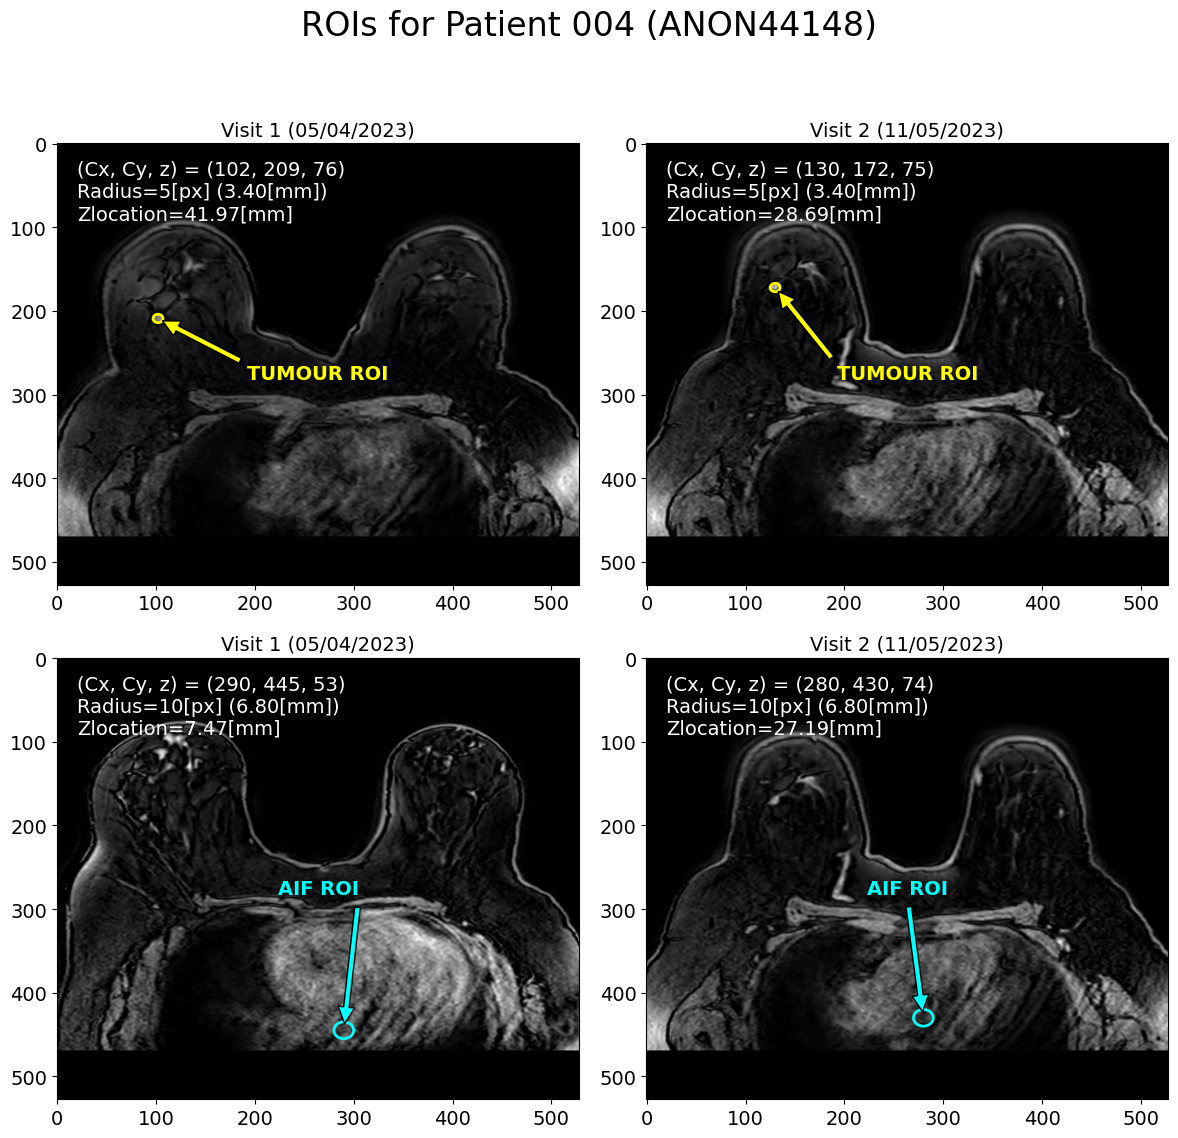

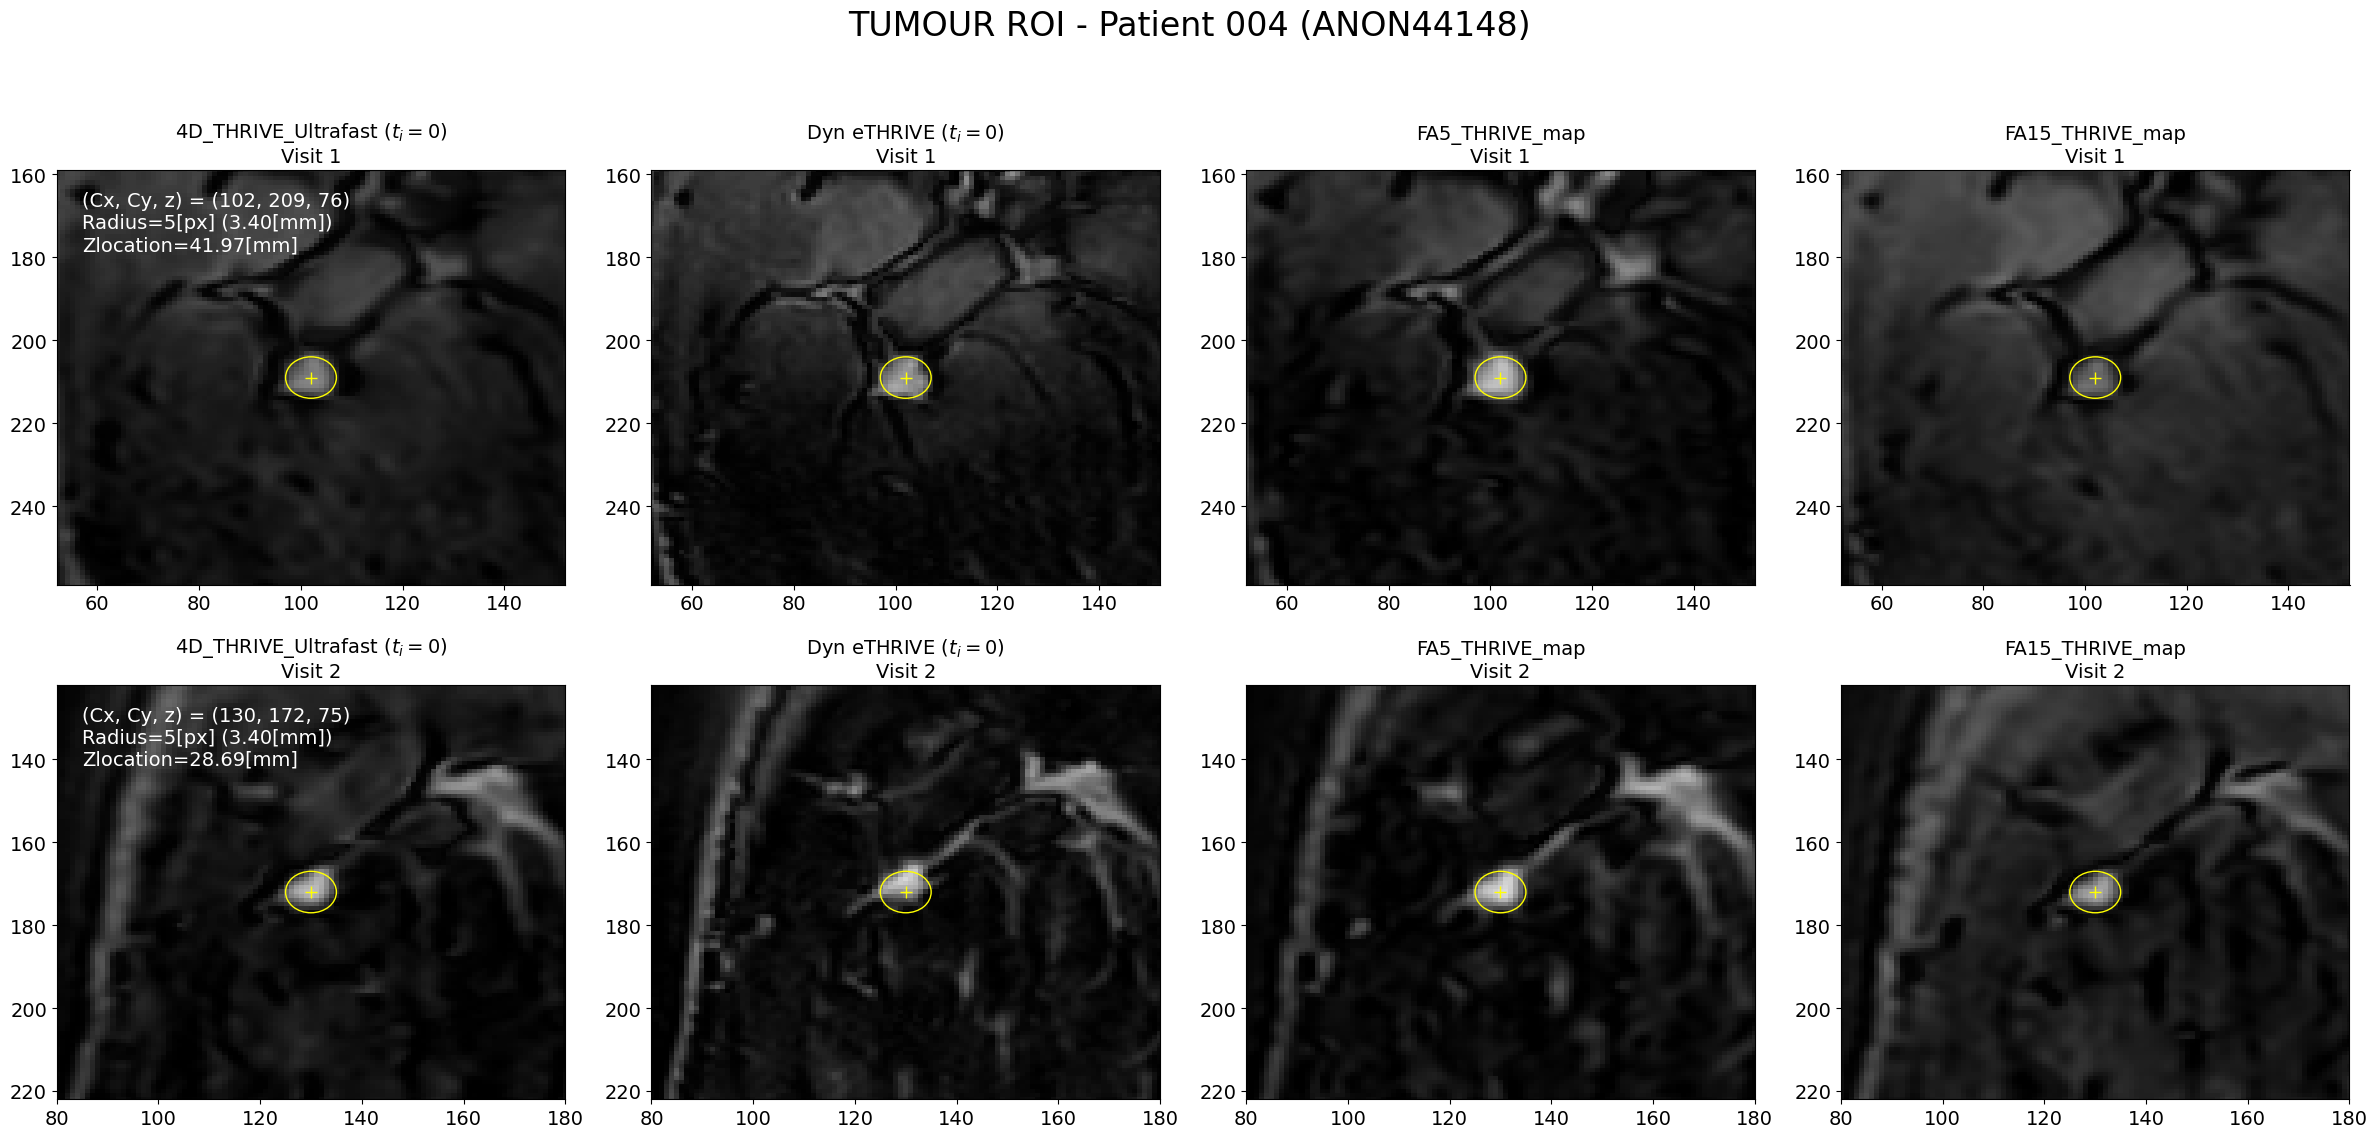

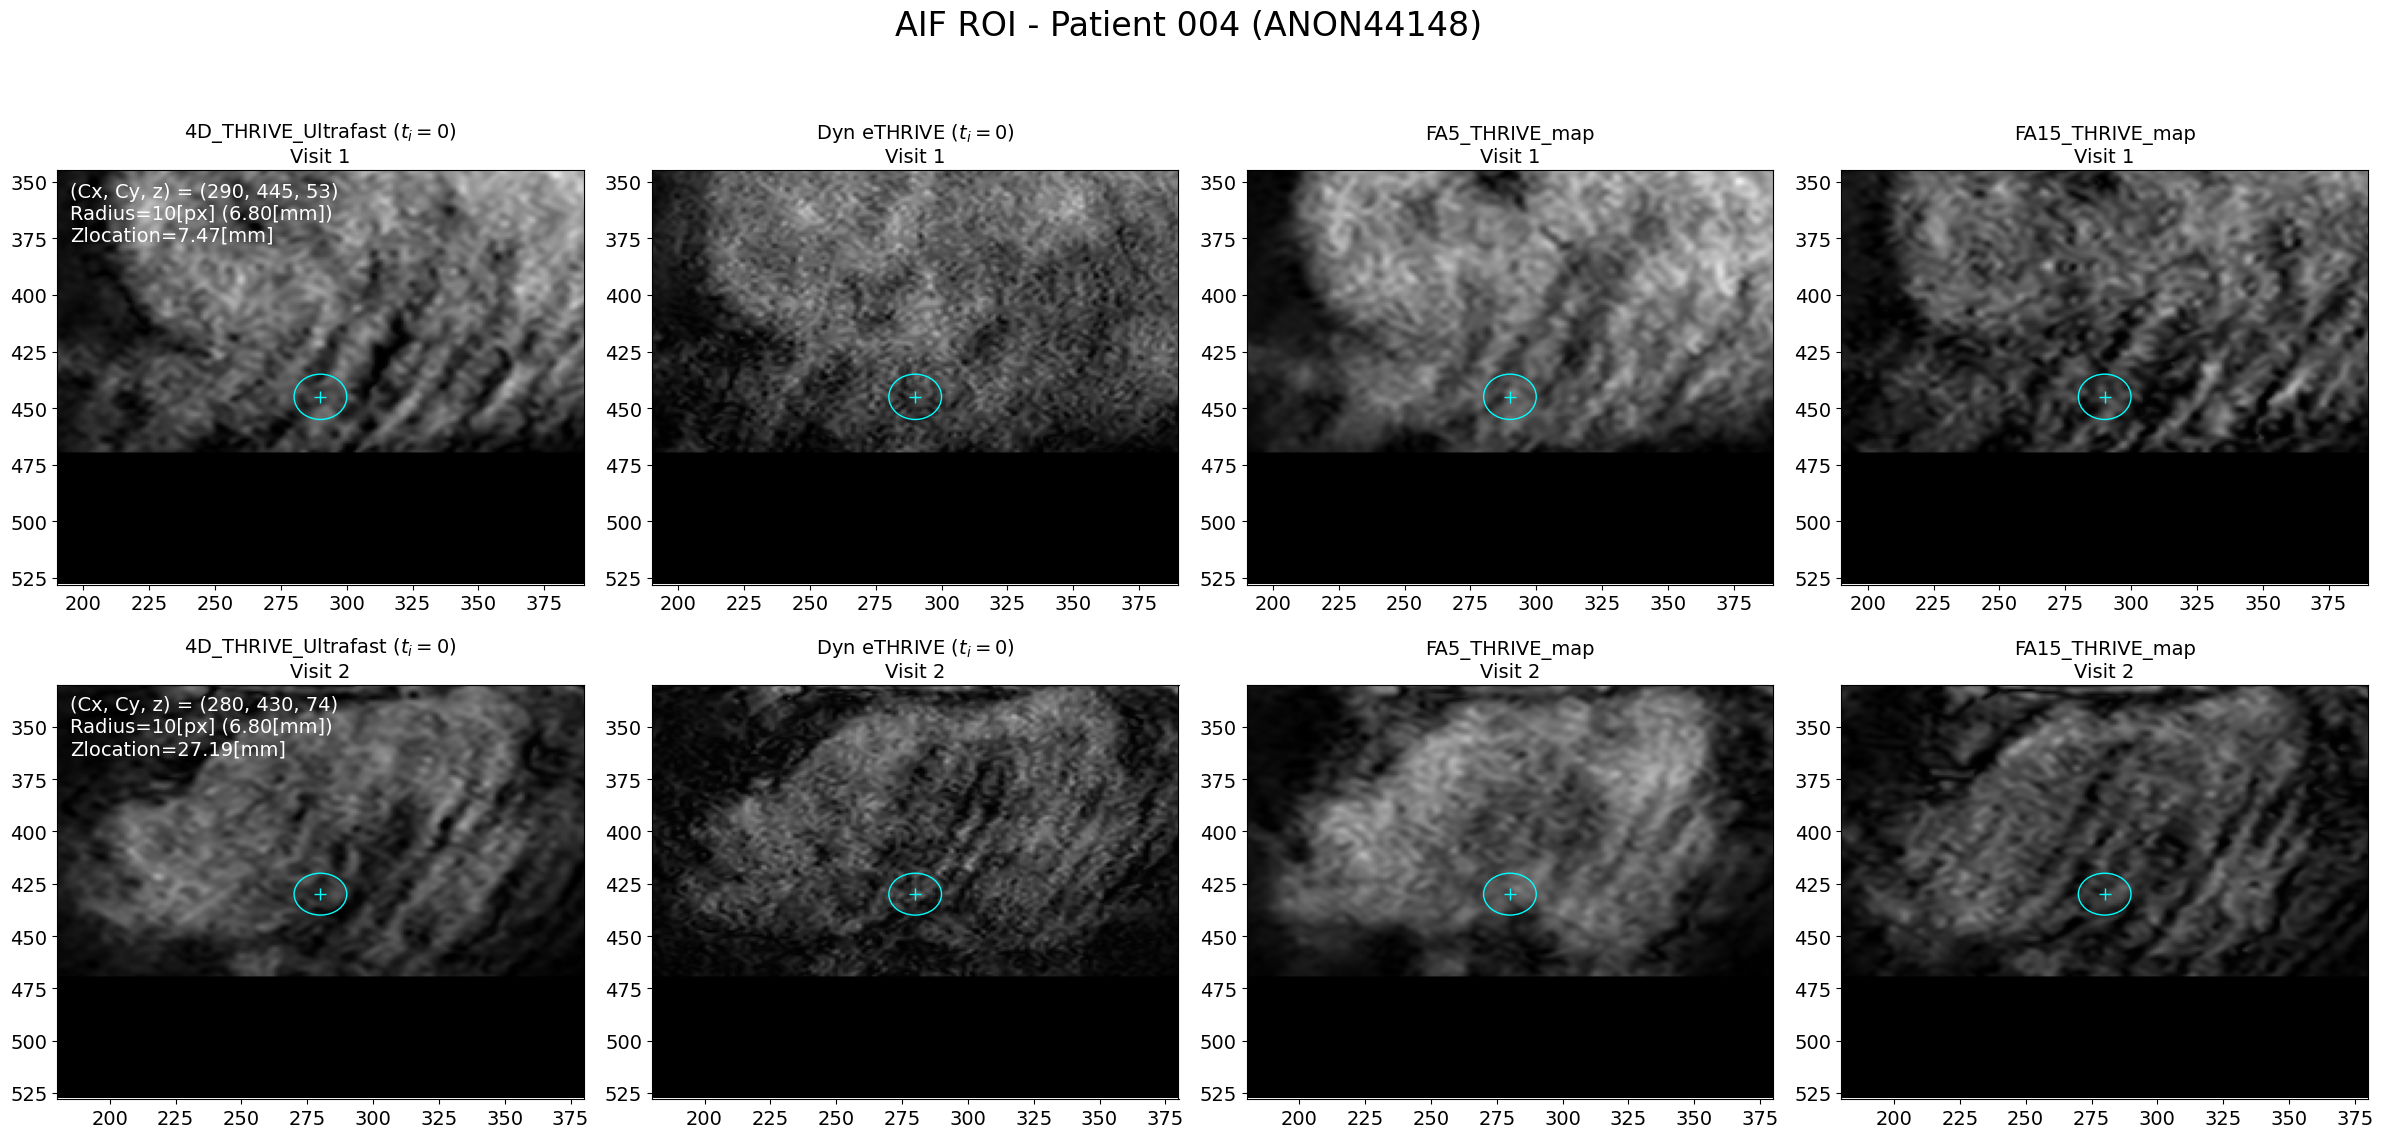

In [85]:
nrows, ncols = [ len(patient_df['Visits'].keys()), len(sequence_patterns) ]
zoom_factor = 10 # factor to zoom in, based on the ROI bounding box, e.g. zoom_factor=1 ==> 100% image view is 2 * RADIUS

fig_fullsize, ax_fullsize = plt.subplots(nrows=2, ncols=2, figsize= (6.0 * 2, 6.0 * 2))

for idanat, anatomy in enumerate(anatomies):

    fig, ax = plt.subplots(nrows = nrows, ncols = ncols, figsize=( 6.0 * ncols, 6.0 * nrows ))
    for visitNro, visitData in patient_df['Visits'].items():
        roi_coordinates_dict['PatientID'].append(patientIDnro)
        roi_coordinates_dict['Anatomy'].append(anatomy)
        roi_coordinates_dict['Visit'].append(visitNro)
        [x, y, z] = tsp[anatomy][visitNro]['point']
        radius = tsp[anatomy][visitNro]['bbox_radius']
        xybox = tsp[anatomy][visitNro]['bbox']

        xmm, ymm = visitData['Sequences']['4D']['metadata']['ScanDetails']['spacing'][:2]
        zmm = visitData['Sequences']['4D']['metadata']['SliceMatrix'][z, 0]
        roi_coordinates_dict['Cx Px'].append(x)
        roi_coordinates_dict['Cy Px'].append(y)
        roi_coordinates_dict['Cx mm'].append(x * xmm)
        roi_coordinates_dict['Cy mm'].append(y * ymm)
        roi_coordinates_dict['Radius px'].append(radius)
        roi_coordinates_dict['Radius mm'].append(radius * np.linalg.norm([xmm, ymm]))
        roi_coordinates_dict['Zlocation px'].append(z)
        roi_coordinates_dict['Zlocation mm'].append( zmm )

        anat_ax = ax_fullsize[idanat, visitNro - 1]
        full_size_img = visitData['Sequences']['4D']['nparray'][0, z, :, :]
        [w, h] = full_size_img.shape
        radius_mm = radius * visitData['Sequences']['4D']['metadata']['ScanDetails']['spacing'][0]
        anat_ax.imshow(full_size_img, 
                       cmap='gray', aspect='auto')#, norm=scale_norm)
        # if anatomy == 'tumour':
        circle = plt.Circle((x, y), radius, color=shade_color[anatomy], fill=False, linewidth=2 * lwidth)
        anat_ax.add_artist(circle)
        anat_ax.text(20, 20,
                    f"(Cx, Cy, z) = ({x}, {y}, {z})\nRadius={radius}[px] ({radius_mm:.2f}[mm])\nZlocation={visitData['Sequences']['4D']['metadata']['SliceMatrix'][z, 0]:.2f}[mm]", 
                    color='w', va='top')
        anat_ax.set_title(f"Visit {visitNro} ({dtime.strftime(visitData['Date'], '%d/%m/%Y')})")
        # fig_fullsize.colorbar(cbar, ax = anat_ax)
        # if anatomy == 'aif':
        #     anat_ax.annotate(f'No {anatomy.upper()} View', color=shade_color[anatomy], fontweight='bold',
        #                     xy=(x, y), xycoords='data',
        #                     xytext=(w//2, h//2), textcoords='data',
        #                     arrowprops=dict(facecolor=shade_color[anatomy], shrink=0.05),
        #                     horizontalalignment='center', verticalalignment='top')
        # else:
        anat_ax.annotate(f'{anatomy.upper()} ROI', color=shade_color[anatomy], fontweight='bold',
                        xy=(x, y), xycoords='data',
                        xytext=(w//2, h//2), textcoords='data',
                        arrowprops=dict(facecolor=shade_color[anatomy], shrink=0.05),
                        horizontalalignment='center', verticalalignment='top')


        for idx, sequence in enumerate(sequence_patterns):
            img_title = visitData['Sequences'][sequence]['metadata']['ScanDetails']['sequenceName']
        
            volume_to_review = visitData['Sequences'][sequence]['nparray']
            if np.ndim(volume_to_review) > 3:
                image_to_display = visitData['Sequences'][sequence]['nparray'][0, z, :, :]
                img_title += r' $(t_i=0)$'
            else:
                image_to_display = visitData['Sequences'][sequence]['nparray'][z, :, :]

            img_list = [image_to_display]
            scale_norm = colors.Normalize(vmin=np.min(img_list),
                                        vmax=np.max(img_list))

            
            curr_ax = ax[visitNro - 1, idx] 
            cbar = curr_ax.imshow(image_to_display, cmap='gray', aspect='auto', norm=scale_norm)
            curr_ax.plot(x, y, '+', color = shade_color[anatomy], markersize=8)
            circle = plt.Circle((x, y), radius, color = shade_color[anatomy], fill=False, linewidth=lwidth)
            curr_ax.add_artist(circle)
            curr_ax.set_title(f'{img_title}\nVisit {visitNro}')
            # fig.colorbar(cbar, ax = curr_ax)
            curr_ax.axis([np.max([0, x - (zoom_factor * radius)]), np.min([x + (zoom_factor * radius), w]),
                          np.min([h, y + (zoom_factor * radius)]), np.max([0, y - (zoom_factor * radius)])])
            if idx == 0:
                curr_ax.text(np.max([0, x - (zoom_factor * radius)])+5, 
                            np.max([0, y - (zoom_factor * radius)])+5,
                            f"(Cx, Cy, z) = ({x}, {y}, {z})\nRadius={radius}[px] ({radius_mm:.2f}[mm])\nZlocation={visitData['Sequences']['4D']['metadata']['SliceMatrix'][z, 0]:.2f}[mm]", 
                            color='w', va='top')

            # cbar[1] = ax[idx, 1].imshow(patient_df['Visits'][visitNro]['Sequences'][sequence]['nparray_proc'][z, :, :], cmap='gray', aspect='auto', norm=scale_norm)
            # ax[idx, 1].plot(x, y, 'y*', markersize=2)
            # circle = plt.Circle((x, y), radius, color='yellow', fill=False, linewidth=lwidth)
            # ax[idx, 1].add_artist(circle)

            # # ax[idx, 1].plot(xybox[0::2], [xybox[1]]*2, 'y-.', linewidth = lwidth)
            # # ax[idx, 1].plot([xybox[0]]*2, xybox[1::2], 'y-.', linewidth = lwidth)
            # # ax[idx, 1].plot(xybox[0::2], [xybox[3]]*2, 'y-.', linewidth = lwidth)
            # # ax[idx, 1].plot([xybox[2]]*2, xybox[1::2], 'y-.', linewidth = lwidth)
            # ax[idx, 1].set_title(f'Pre-processed - {sequence}')
            # fig.colorbar(cbar[1], ax=ax[idx, 1])
            # # ax[idx, 1].axis([50,150,190,230])
            
            # absDiff = np.log(np.abs(patient_df['Visits'][visitNro]['Sequences'][sequence]['nparray'][z, :, :] - 
            #                         patient_df['Visits'][visitNro]['Sequences'][sequence]['nparray_proc'][z, :, :]) + 1e-3)
            # log_scale = colors.Normalize(vmin=np.min(absDiff), vmax=np.max(absDiff))

            # cbar[2] = ax[idx, 2].imshow( absDiff + 1e-3, cmap='gray', aspect='auto')#, norm=scale_norm)
            # ax[idx, 2].set_title(r'$\log(\| RAW - PREPROC\|)$')
            # fig.colorbar(cbar[2], ax=ax[idx, 2])
        # fig.suptitle(f"Patient {patientIDnro} ({patientID}) - Visit {visitNro} ({dtime.strftime(patient_df['Visits'][visitNro]['Date'], '%d/%m/%Y')})")
    fig.suptitle(f"{anatomy.upper()} ROI - Patient {patientIDnro} ({patientID})")
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.savefig(os.path.join(PRELIMPATH, 'roi_match', '.'.join([f'patient{patientIDnro}_{anatomy}ROI', 'png'])), bbox_inches='tight')
fig_fullsize.suptitle(f"ROIs for Patient {patientIDnro} ({patientID})")
fig_fullsize.tight_layout(rect=[0, 0.03, 1, 0.95])
fig_fullsize.savefig(os.path.join(PRELIMPATH, 'roi_match', '.'.join([f'patient{patientIDnro}_ROIs', 'png'])), bbox_inches='tight')


### Average Signal Intensity

In [ ]:
if patientIDnro == '009':
    roi_coord_dataframe = pd.DataFrame.from_dict(roi_coordinates_dict)
    roi_coord_dataframe.to_csv(os.path.join(PRELIMPATH, 'roi_match', 'roi_coord.csv'))
    roi_coord_dataframe.head()


Volume size: (1, 120, 528, 528, 28)
Metadata: {'origin': array([ -72.02628326, -149.2262471 , -171.38574484,    0.        ]), 'spacing': array([1.5       , 0.67961162, 0.67961162, 3.6       ]), 'direction': array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])}
Volume size: (1, 120, 528, 528, 28)
Metadata: {'origin': array([ -83.80986023, -159.04588822, -181.20538762,    0.        ]), 'spacing': array([1.5       , 0.67961162, 0.67961162, 3.59      ]), 'direction': array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])}
Volume size: (1, 120, 528, 528, 28)
Metadata: {'origin': array([ -65.15252686, -143.33447197, -168.4398568 ,    0.        ]), 'spacing': array([1.5       , 0.67961162, 0.67961162, 3.59      ]), 'direction': array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])}
Volume size: (1, 120, 528, 528, 28)
Metadata: {'origin': array([ -65.1525

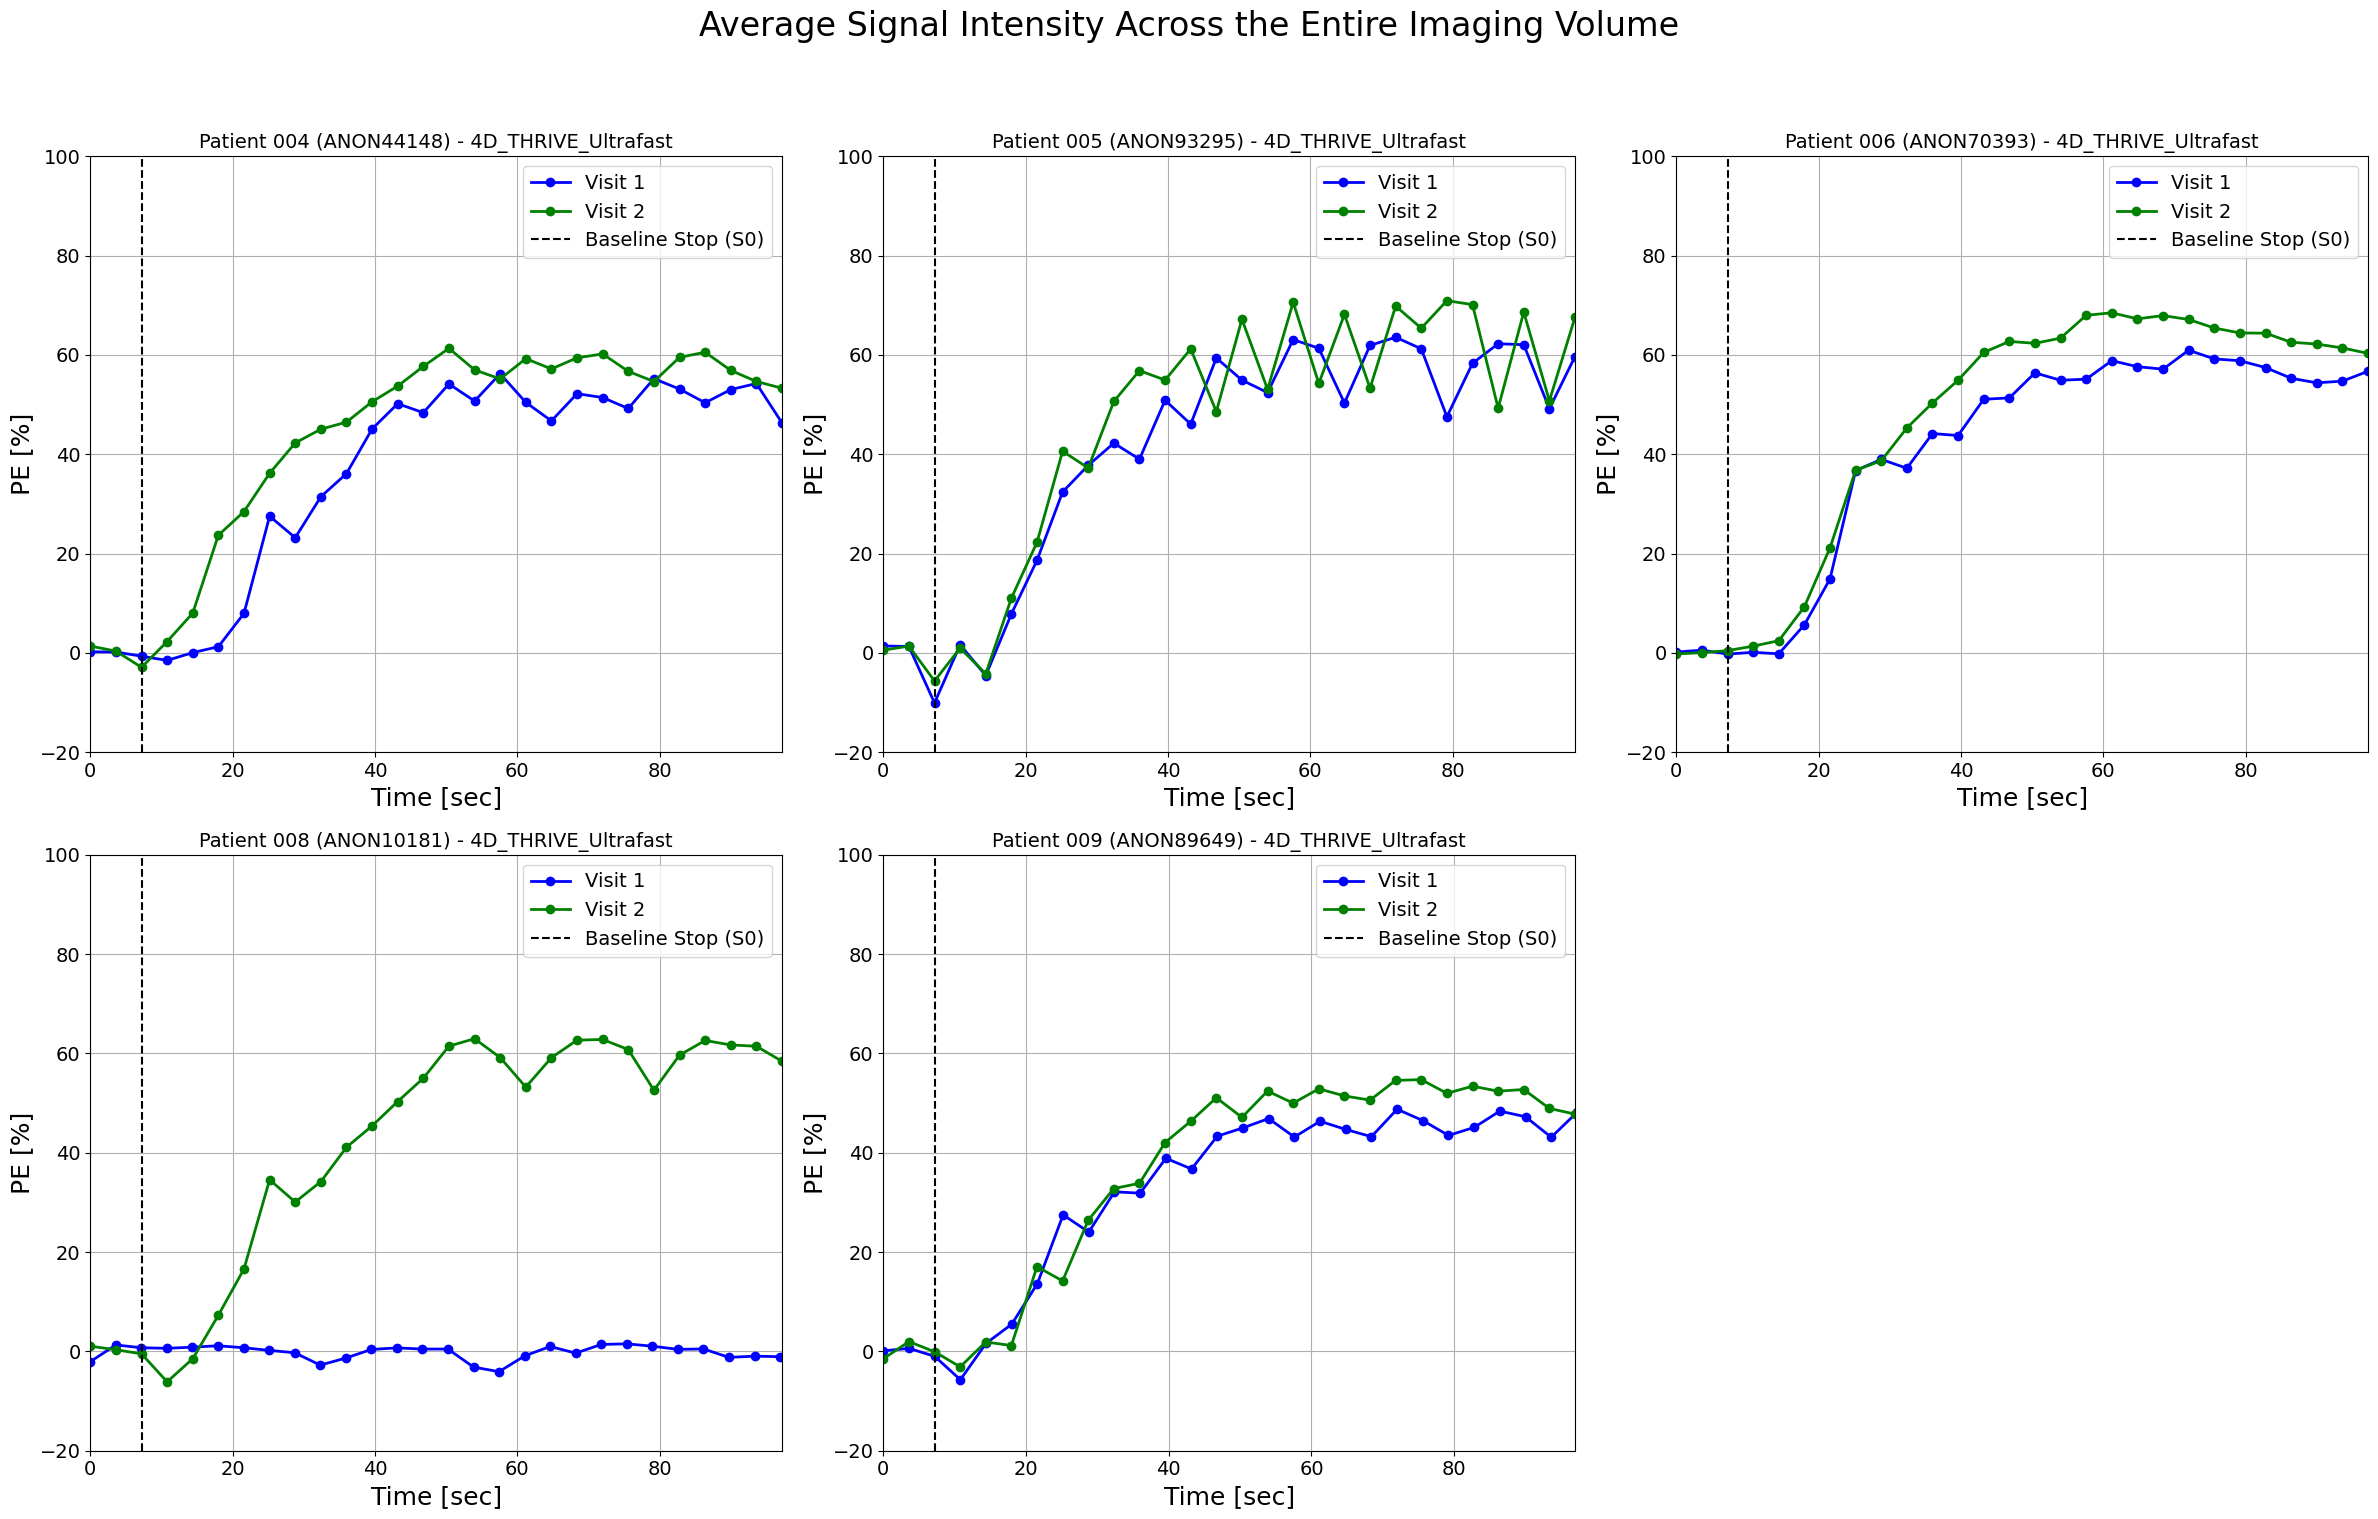

In [101]:
if patientIDnro == '004':

    patients_to_plot = ['004', '005', '006', '008', '009']
    sequence_to_plot = '4D'
    nfigs = len(patients_to_plot)
    ncols = np.ceil(np.sqrt(nfigs))
    nrows = np.ceil(nfigs / nrows)
    fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(fig_width * ncols, fig_height * nrows))
    axr = ax.ravel()
    visit_colour = {1: 'blue',
                    2: 'green'}

    for idx, patient_i in enumerate(patients_to_plot):
        patientID = patientsID[patient_i]
        patient_i_df = load_patient_data(dicom_dataframe, patientID, [sequence_to_plot], usePhilipsReScale)
        for visitNro, visitData in patient_i_df['Visits'].items():
            sequence_name = visitData['Sequences'][sequence_to_plot]['metadata']['ScanDetails']['sequenceName']
            dynamic_series = visitData['Sequences'][sequence_to_plot]['nparray']
            time_axis = visitData['Sequences'][sequence_to_plot]['metadata']['TimeMatrix'][0, :]

            dt = np.median(np.diff(time_axis))
            bat = 3
            uniform_time = np.linspace(0.0, dt * len(time_axis), len(time_axis), endpoint=False)

            baseline_si = np.median(dynamic_series[:bat,:,:,:], axis=0)
            s0 = np.mean(baseline_si)

            mean_st = np.zeros_like(time_axis)
            for tpoint in range(len(time_axis)):
                st_slice = dynamic_series[tpoint, :, :, :].copy()
                mean_st[tpoint] = np.mean(st_slice - baseline_si)

            mean_st /= s0
            mean_st *= 100.0

            axr[idx].plot(uniform_time, mean_st, '.-', 
                          color=visit_colour[visitNro], linewidth = 2 * lwidth, markersize=12,
                          label=f'Visit {visitNro}')
        axr[idx].plot([uniform_time[bat-1]]*2, [-20, 100], 'k--', label='Baseline Stop (S0)')
        axr[idx].set_title(f'Patient {patient_i} ({patientID}) - {sequence_name}')
        axr[idx].set_ylim([-20.0, 100.0])
        axr[idx].set_xlim([uniform_time[0], uniform_time[-1]])
        axr[idx].grid(True)
        axr[idx].legend(loc='upper right')
        axr[idx].set_xlabel('Time [sec]')
        # axr[idx].set_ylabel(r'$\frac{S(t) - S0}{S0}$[%]')
        axr[idx].set_ylabel('PE [%]')

    idx += 1
    while idx < (nrows * ncols):
        axr[idx].remove()
        idx += 1

    fig.suptitle('Average Signal Intensity Across the Entire Imaging Volume')
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.savefig(os.path.join(PRELIMPATH, 'qc_figures', 'avg_signal_all_patients.png'), bbox_inches='tight')


Volume size: (1, 120, 528, 528, 28)
Metadata: {'origin': array([ -72.02628326, -149.2262471 , -171.38574484,    0.        ]), 'spacing': array([1.5       , 0.67961162, 0.67961162, 3.6       ]), 'direction': array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])}
Volume size: (1, 120, 528, 528, 28)
Metadata: {'origin': array([ -83.80986023, -159.04588822, -181.20538762,    0.        ]), 'spacing': array([1.5       , 0.67961162, 0.67961162, 3.59      ]), 'direction': array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])}
Patient: 004
[x,y,z, radius]: [102,209,76, 5]
Mean St[0]: -36.022593557098766]
Patient: 004
[x,y,z, radius]: [130,172,75, 5]
Mean St[0]: 218.37772472993828]


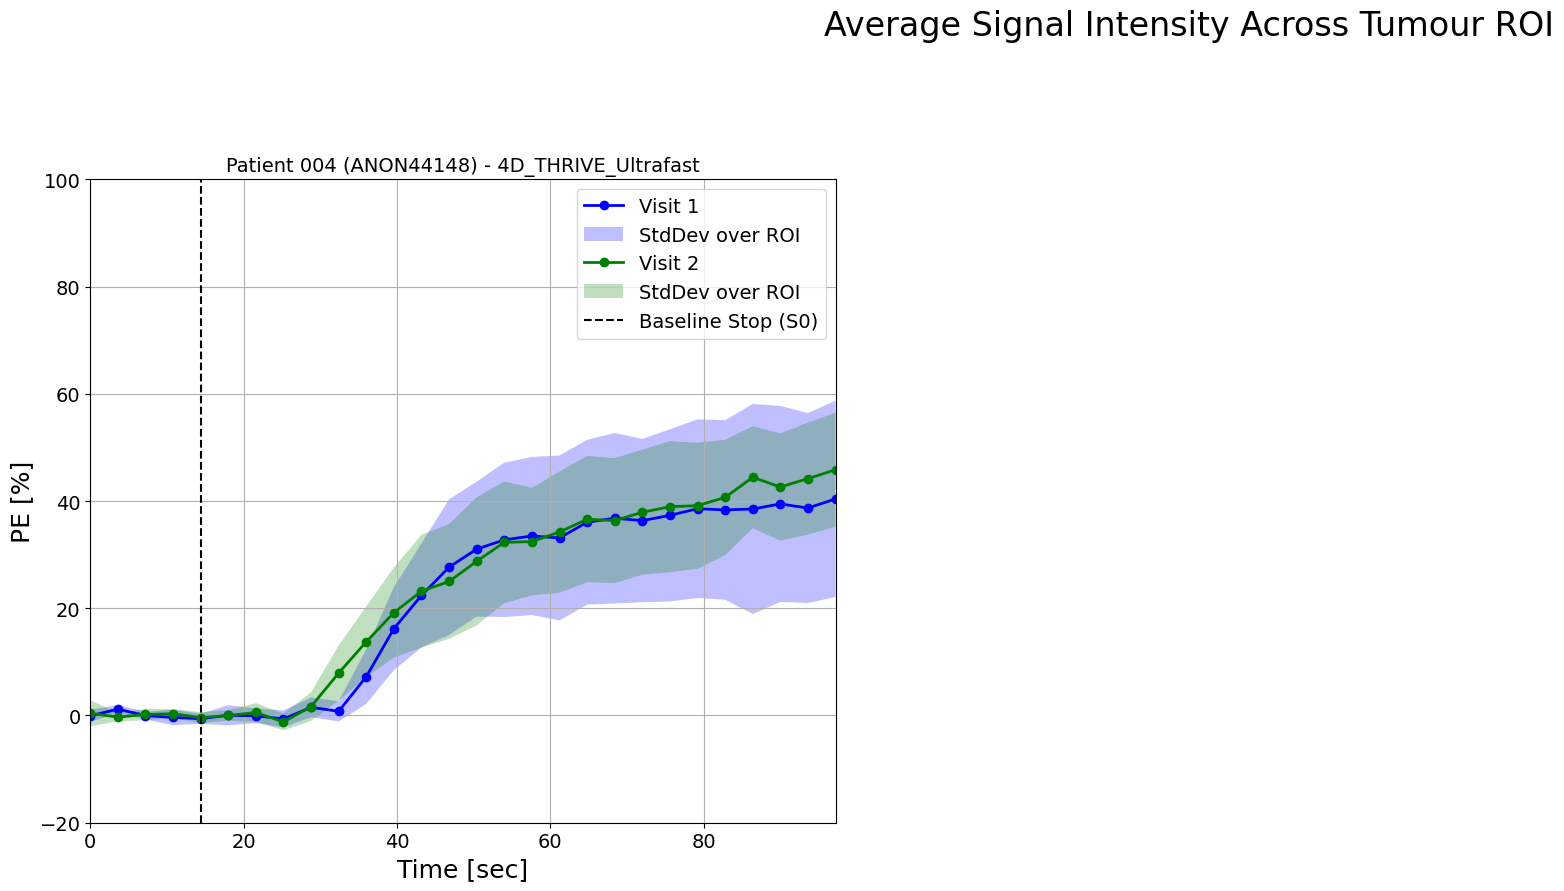

In [ ]:
if patientIDnro == '009':

    patients_to_plot = ['004', '005', '006', '008', '009']
    sequence_to_plot = '4D'
    nfigs = len(patients_to_plot)
    ncols = np.ceil(np.sqrt(nfigs))
    nrows = np.ceil(nfigs / nrows)
    fig, ax = plt.subplots(nrows=int(nrows), ncols=int(ncols), figsize=(fig_width * ncols, fig_height * nrows))
    axr = ax.ravel()
    visit_colour = {1: 'blue',
                    2: 'green'}

    for idx, patient_i in enumerate(patients_to_plot):
        patientID = patientsID[patient_i]
        patient_i_df = load_patient_data(dicom_dataframe, patientID, [sequence_to_plot], usePhilipsReScale)
        reference_slice_location = {'tumour': TUMOUR_coord_df.loc[TUMOUR_coord_df['PatientID'] == patientID],
                                    }
        for visitNro, visitData in patient_i_df['Visits'].items():
            ref_coords = reference_slice_location['tumour'][reference_slice_location['tumour']['StudyDate'].isin([int(visitData['VisitID'])])]
            zlocations = visitData['Sequences'][sequence_to_plot]['metadata']['SliceMatrix']
            closest_zindex = int(np.argmin(np.abs(zlocations[:,0] - ref_coords['ImagePatientPosZ'].values[0])))
            # troi = {'point': }
            [x, y, z] = ref_coords[['Cx','Cy']].values.flatten().tolist() + [closest_zindex]
            xoffset = int(np.ceil(ref_coords['Radius'].values[0] / 2))
            yoffset = xoffset
            bbox = [int(np.max([x - xoffset, 0])), # xupperleft
                    int(np.max([y - yoffset, 0])), # yupperleft
                    int(x + xoffset), #xlowerright
                    int(y + yoffset)  #ylowerright
                    ]
            radius = ref_coords['Radius'].values[0]

            # Create a mask that can be used to get more precise summaries:
            # Get image size reference from the T1W VFA images:
            image_mask = np.zeros_like(patient_df['Visits'][visitNro]['Sequences'][sequence_to_plot]['nparray'][0, 0, :, :], dtype="uint8")
            cv2.circle(image_mask, [x, y], radius, [255]*1, -1)


            sequence_name = visitData['Sequences'][sequence_to_plot]['metadata']['ScanDetails']['sequenceName']
            dynamic_series = visitData['Sequences'][sequence_to_plot]['nparray']
            time_axis = visitData['Sequences'][sequence_to_plot]['metadata']['TimeMatrix'][0, :]

            dt = np.median(np.diff(time_axis))
            bat = 5
            uniform_time = np.linspace(0.0, dt * len(time_axis), len(time_axis), endpoint=False)

            baseline_signal = np.median(dynamic_series[:bat,z,:,:], axis=0)
            baseline_si = np.mean(baseline_signal[image_mask > 0])

            mean_st = np.zeros_like(time_axis)
            std_st = np.zeros_like(time_axis)
            for tpoint in range(len(time_axis)):
                st_wholeslice = dynamic_series[tpoint, z, :, :].copy()
                st_wholeslice -= baseline_signal
                st_slice = st_wholeslice[image_mask > 0]

                mean_st[tpoint] = np.mean(st_slice )#- baseline_si) 
                std_st[tpoint] = np.std(st_slice )#- baseline_si)

            print(f'Patient: {patientIDnro}')
            print(f'[x,y,z, radius]: [{x},{y},{z}, {radius}]')
            print(f'Mean St[0]: {mean_st[0]}]')

            mean_st *= ( 100.0 / baseline_si )
            std_st  *= ( 100.0 / baseline_si )

            
            upper_band, lower_band = [mean_st + std_st, mean_st - std_st]

            axr[idx].plot(uniform_time, mean_st, '.-', 
                          color=visit_colour[visitNro], linewidth = 2 * lwidth, markersize=12,
                          label=f'Visit {visitNro}')
            axr[idx].fill_between(uniform_time, upper_band, lower_band, 
                                  facecolor=visit_colour[visitNro], alpha=0.25, interpolate=True, label='StdDev over ROI')

            
        axr[idx].plot([uniform_time[bat-1]]*2, [-20, 100], 'k--', label='Baseline Stop (S0)')
        axr[idx].set_title(f'Patient {patient_i} ({patientID}) - {sequence_name}')
        axr[idx].set_ylim([-20.0, 100.0])
        axr[idx].set_xlim([uniform_time[0], uniform_time[-1]])
        axr[idx].grid(True)
        axr[idx].legend(loc='best')
        axr[idx].set_xlabel('Time [sec]')
        # axr[idx].set_ylabel(r'$\frac{S(t) - S0}{S0}$[%]')
        axr[idx].set_ylabel('PE [%]')

    idx += 1
    while idx < (nrows * ncols):
        axr[idx].remove()
        idx += 1

    fig.suptitle('Average Signal Intensity Across Tumour ROI')
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.savefig(os.path.join(PRELIMPATH, 'qc_figures', 'avg_tumour_all_patients.png'), bbox_inches='tight')
